# Attribute Mining Parameter Sweep — EDA

Cross-configuration EDA of the attribute-mining pipeline, over the sweep grid
`sweep_attribute_schema.py` writes to
`artifacts/mining/*_symbolic_{scenario}_*gran*_win*/attribute_mining/`. Mining runs
in two stages: **Step 1** (`thesis.mining.attribute_contrast_mining`) filters
categorical contrast-set itemsets by `min_growth_rate` / `min_growth_rate_attack` /
`min_attack_coverage` / `min_benign_coverage`; **Step 2**
(`thesis.mining.decision_tree_rule_mining.fit_and_extract_rules`) fits **two
independent decision trees** over the numeric attributes — `max_depth` for the
benign-leaning tree, `max_depth_attack` for the attack-leaning tree.

Every axis was swept *alone*, holding every other axis at an anchor value in the
*other* stage (plus one small `growth_rate × max_depth_attack` cross-check), so
this is not a full rectangle — `anchored_mask()` below pins every non-varying axis
explicitly. See `sweep_attribute_schema.py`'s module docstring for why one anchor
per stage is sufficient.

**What this notebook answers.**

1. *Baseline* (§2): what the Step-1 selection metrics (`growth_rate`, per-class
   coverage) look like on the full dataset, before any threshold or windowing —
   and whether the swept grids sit near a meaningful elbow of that distribution.
2. *Orthogonality* (§3): are Step 1 and Step 2, and the two tree depths,
   genuinely independent, so one-axis-at-a-time sweeps are valid?
3. *Per-parameter effect* (§4–§5): each hyperparameter's effect on schema
   structure, quality, and temporal stability — which to freeze, which to vary
   (drafted in `summaries/ATTRIBUTE_MINING_PARAMETER_ANALYSIS.md`).
4. *Outcome* (§6): a mining config that clears both an attack-precision and a
   benign-recall floor — the piece the earlier single-tree analysis could not
   reach (0/36 configs cleared both, one shared depth serving neither).

> **History.** An earlier version analysed a single-tree Step 2 grid. Fitting two
> trees is a different algorithm and a full re-mine — none of those run
> directories feed anything here. A few age-based lifecycle views built on the
> single-tree grid are not yet ported (see §3.4).

## 1. Setup

In [1]:
from __future__ import annotations

import ast
import gc
import json
import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# --- scenario / paths --------------------------------------------------------
# SCENARIO, the sweep-grid location, the anchors, and the grid value lists are all
# imported from sweep_attribute_schema.py -- the script that *writes* the grid --
# so the notebook that *reads* it can never drift out of sync. Only "cscas" has a
# sweep grid today; load_scenario_alert_groups() raises for anything else.
from thesis.paths import CACHE_DIR
from thesis.scripts.mining_sweep.sweep_attribute_schema import (
    MINING_ROOT,
    RUN_NAME_RE,
    SCENARIO,
    STEP1_COVERAGE_GRID,
    STEP1_DEFAULT_ATTACK_COVERAGE,
    STEP1_DEFAULT_BENIGN_COVERAGE,
    STEP1_DEFAULT_GROWTH_RATE,
    STEP1_GROWTH_RATES,
    STEP2_DEFAULT_CLASS_WEIGHT,
    STEP2_DEFAULT_MAX_DEPTH,
    STEP2_DEFAULT_MAX_DEPTH_ATTACK,
    STEP2_DEFAULT_MIN_SAMPLES_LEAF,
)

# Repo root from MINING_ROOT (= <repo>/artifacts/mining), so every output path is
# absolute and independent of the notebook's working directory.
REPO_ROOT = Path(MINING_ROOT).resolve().parents[1]
GRID_ARTIFACT_DIR = REPO_ROOT / "artifacts" / "experiments" / "attribute_mining_parameter_grid"
FIGURES_DIR = GRID_ARTIFACT_DIR / "thesis_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Notebook keeps its own short anchor names, sourced from the sweep script.
STEP1_ANCHOR_GROWTH_RATE = STEP1_DEFAULT_GROWTH_RATE
STEP1_ANCHOR_ATTACK_COVERAGE = STEP1_DEFAULT_ATTACK_COVERAGE
STEP1_ANCHOR_BENIGN_COVERAGE = STEP1_DEFAULT_BENIGN_COVERAGE
STEP2_ANCHOR_MAX_DEPTH = STEP2_DEFAULT_MAX_DEPTH
STEP2_ANCHOR_MAX_DEPTH_ATTACK = STEP2_DEFAULT_MAX_DEPTH_ATTACK
STEP2_ANCHOR_CLASS_WEIGHT = STEP2_DEFAULT_CLASS_WEIGHT
STEP2_ANCHOR_MIN_SAMPLES_LEAF = STEP2_DEFAULT_MIN_SAMPLES_LEAF

# --- colours ---------------------------------------------------------------
GRAN_PALETTE = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377"]
ATTACK_COLOR = "#CC3311"   # warm -> attack-leaning / attack class
BENIGN_COLOR = "#4477AA"   # cool -> benign-leaning / benign class
NEUTRAL_COLOR = "#BBBBBB"


def gran_color_map(grans) -> dict:
    return {g: GRAN_PALETTE[i % len(GRAN_PALETTE)] for i, g in enumerate(sorted(grans))}


def savefig(fig, name: str) -> None:
    """Save a 300dpi copy for the thesis alongside the inline display."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  saved {path}")


def strip_axes(ax) -> None:
    ax.grid(axis="y", alpha=0.25)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def base_feature(token: str) -> str:
    """'NOT_multi_target' -> 'multi_target';
    'signature_matches_per_day_le_143.7' -> 'signature_matches_per_day'."""
    t = token.strip()
    if t.startswith("NOT_"):
        t = t[4:]
    m = re.match(r"^(.*)_(le|gt)_[-0-9.eE]+$", t)
    return m.group(1) if m else t


def load_scenario_alert_groups(scenario: str):
    """Un-windowed alert groups for the whole scenario, from the same on-disk
    cache the sweep script mines from."""
    if scenario == "cscas":
        from thesis.pipeline.pipeline import ingest_cscas_scenario, load_or_build_alert_groups

        cache_dir = CACHE_DIR / scenario / "groups" / "cscas_pregrouped"
        ingest_cscas_scenario(cache_dir=cache_dir)
        groups = load_or_build_alert_groups(scenario, cache_dir)
    else:  # pragma: no cover - no non-cscas sweep grid exists yet
        raise NotImplementedError(
            f"no un-windowed loader wired for scenario {scenario!r} -- add an ingest "
            "branch here (see thesis.pipeline.pipeline.ingest_ait_scenario)"
        )
    groups.sort(key=lambda g: g.start_ts or "")
    return groups


def axis_effect_fig(sweep_df, axis, metrics, *, color=None, per_gran=False,
                    title=None, figname=None, xlabel=None, ylim=None):
    """One row of panels, one per (metric, label), each showing that metric vs
    `axis`. per_gran=True -> one line per granularity; else a single bar series
    (mean +/- std). Returns the grouped-mean table. Replaces the ~identical
    plotting blocks the per-axis sections used to repeat."""
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.7 * len(metrics), 3.2), squeeze=False)
    axes = axes[0]
    for ax, (metric, label) in zip(axes, metrics):
        if per_gran:
            for gran in GRANULARITIES:
                s = sweep_df[sweep_df.gran == gran].groupby(axis, dropna=False)[metric].mean()
                ax.plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6,
                        color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
        else:
            st = sweep_df.groupby(axis, dropna=False)[metric].agg(["mean", "std"])
            ax.bar(st.index.astype(str), st["mean"], yerr=st["std"].fillna(0),
                   color=color or NEUTRAL_COLOR, capsize=3)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel(xlabel or axis)
        if ylim:
            ax.set_ylim(*ylim)
        strip_axes(ax)
    if per_gran:
        axes[0].legend(frameon=False, fontsize=7)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    if figname:
        savefig(fig, figname)
    plt.show()
    return sweep_df.groupby(axis, dropna=False)[[m for m, _ in metrics]].mean().round(3)

In [2]:
_RUN_DIR_CSVS = ("mined_attribute_features.csv", "contrast_stats_all.csv", "contrast_survivors.csv")


def _run_dir_is_valid(mining_dir: Path) -> bool:
    """True if every CSV this notebook reads out of a run_dir parses cleanly -- a
    thread-pool run racing two writers on one path can interleave their byte
    streams into a file that belongs to neither config. Catching it here turns it
    into a printed skip instead of a baffling downstream traceback."""
    for fname in _RUN_DIR_CSVS:
        path = mining_dir / fname
        if not path.exists():
            return False
        try:
            df = pd.read_csv(path)
        except Exception:
            return False
        if "itemset" in df.columns:
            try:
                df["itemset"].apply(ast.literal_eval)
            except Exception:
                return False
    return True


rows, skip_reasons = [], []
for run_dir in sorted(Path(MINING_ROOT).iterdir()):
    m = RUN_NAME_RE.match(run_dir.name)
    if m is None:
        continue
    mining_dir = run_dir / "attribute_mining"
    if not ((mining_dir / "config.yaml").exists() and (mining_dir / "metadata.json").exists()):
        continue
    if not _run_dir_is_valid(mining_dir):
        skip_reasons.append(run_dir.name)
        continue
    cfg = yaml.safe_load((mining_dir / "config.yaml").read_text())
    meta = json.loads((mining_dir / "metadata.json").read_text())
    rows.append({
        "run_dir": run_dir.name,
        "growth_rate": cfg["contrast"]["min_growth_rate"],
        "min_growth_rate_attack": cfg["contrast"].get("min_growth_rate_attack"),
        "max_depth": cfg["tree"]["max_depth"],
        "max_depth_attack": cfg["tree"].get("max_depth_attack"),
        "min_attack_coverage": cfg["contrast"]["min_attack_coverage"],
        "min_benign_coverage": cfg["contrast"]["min_benign_coverage"],
        "class_weight": cfg["tree"]["class_weight"],
        "min_samples_leaf": cfg["tree"]["min_samples_leaf"],
        "gran": float(m.group(1)),
        "win_idx": int(m.group(2)),
        "n_alert_groups": meta["n_alert_groups"],
        "mining_dir": mining_dir,
    })

_AXES = ["growth_rate", "min_growth_rate_attack", "max_depth", "max_depth_attack",
         "class_weight", "min_samples_leaf", "min_attack_coverage", "min_benign_coverage"]
grid_df = (
    pd.DataFrame(rows)
    .drop_duplicates(subset=_AXES + ["gran", "win_idx"], keep="last")
    .sort_values(["growth_rate", "min_growth_rate_attack", "max_depth", "max_depth_attack", "gran", "win_idx"])
    .reset_index(drop=True)
)

GROWTH_RATES = sorted(grid_df["growth_rate"].unique())
GROWTH_RATES_ATTACK = sorted(grid_df["min_growth_rate_attack"].dropna().unique())
MAX_DEPTHS = sorted(grid_df["max_depth"].unique())
MAX_DEPTHS_ATTACK = sorted(grid_df["max_depth_attack"].dropna().unique())
GRANULARITIES = sorted(grid_df["gran"].unique())

# Anchor each axis is held at while some *other* axis is swept. min_growth_rate_attack's
# anchor is NaN ("no split"): the sweep never crosses it with anything, so pinning it
# keeps its rows out of every other axis's mask.
_ANCHORS = {
    "growth_rate": STEP1_ANCHOR_GROWTH_RATE,
    "min_growth_rate_attack": np.nan,
    "max_depth": STEP2_ANCHOR_MAX_DEPTH,
    "max_depth_attack": STEP2_ANCHOR_MAX_DEPTH_ATTACK,
    "class_weight": STEP2_ANCHOR_CLASS_WEIGHT,
    "min_samples_leaf": STEP2_ANCHOR_MIN_SAMPLES_LEAF,
    "min_attack_coverage": STEP1_ANCHOR_ATTACK_COVERAGE,
    "min_benign_coverage": STEP1_ANCHOR_BENIGN_COVERAGE,
}


def anchored_mask(*vary: str) -> pd.Series:
    """Rows of grid_df with every axis at its anchor EXCEPT those named in `vary`.
    Replaces the hand-written *_SWEEP_MASK constants: anchored_mask("growth_rate")
    is the old GROWTH_RATE_SWEEP_MASK, anchored_mask("min_attack_coverage",
    "min_benign_coverage") the old COVERAGE_SWEEP_MASK, and so on."""
    mask = pd.Series(True, index=grid_df.index)
    for axis, anchor in _ANCHORS.items():
        if axis in vary:
            continue
        col = grid_df[axis]
        is_nan_anchor = isinstance(anchor, float) and np.isnan(anchor)
        mask &= col.isna() if is_nan_anchor else (col == anchor)
    return mask


GROWTH_RATE_SWEEP_MASK = anchored_mask("growth_rate")
MAX_DEPTH_SWEEP_MASK = anchored_mask("max_depth")
MAX_DEPTH_ATTACK_SWEEP_MASK = anchored_mask("max_depth_attack")
COVERAGE_SWEEP_MASK = anchored_mask("min_attack_coverage", "min_benign_coverage")
CLASS_WEIGHT_SWEEP_MASK = anchored_mask("class_weight")
# min_growth_rate_attack sweep: free that axis; growth_rate stays at its 3.0 anchor
# (the None row IS growth_rate=3.0, this axis's "no split" reference point).
GROWTH_RATE_ATTACK_SWEEP_MASK = anchored_mask("min_growth_rate_attack")
CROSS_CHECK_MASK = (
    anchored_mask("growth_rate", "max_depth_attack")
    & grid_df["growth_rate"].isin([2.0, 10.0])
    & grid_df["max_depth_attack"].isin([1, 5])
)
ANCHOR_MASK = GROWTH_RATE_SWEEP_MASK & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)


def _check_axis_completeness(label: str, mask: pd.Series, group_col: str) -> None:
    sub = grid_df[mask]
    ok = True
    for gran in sorted(sub["gran"].unique()):
        win_sets = sub[sub.gran == gran].groupby(group_col)["win_idx"].apply(lambda s: frozenset(s))
        if win_sets.nunique() > 1:
            print(f"  WARNING: {label} @ gran={gran:g} inconsistent window coverage: {win_sets.to_dict()}")
            ok = False
    if ok:
        print(f"  OK: {label} -- consistent window coverage across every {group_col}, every granularity")


if skip_reasons:
    print(f"Skipped {len(skip_reasons)} run_dir(s) with corrupted CSVs: {skip_reasons}")
print(f"Found {len(grid_df)} mining runs (deduped) under {Path(MINING_ROOT).resolve()}")
print(f"growth_rate={[float(g) for g in GROWTH_RATES]}  "
      f"growth_rate_attack={[float(g) for g in GROWTH_RATES_ATTACK]}  "
      f"max_depth={[int(d) for d in MAX_DEPTHS]}  max_depth_attack={[int(d) for d in MAX_DEPTHS_ATTACK]}  "
      f"granularity={[float(g) for g in GRANULARITIES]}")
for gran in GRANULARITIES:
    print(f"  gran={gran:g}: {grid_df[grid_df.gran == gran]['win_idx'].nunique()} window(s)")
print()
_check_axis_completeness("growth_rate sweep", GROWTH_RATE_SWEEP_MASK, "growth_rate")
_check_axis_completeness("max_depth (benign) sweep", MAX_DEPTH_SWEEP_MASK, "max_depth")
_check_axis_completeness("max_depth_attack sweep", MAX_DEPTH_ATTACK_SWEEP_MASK, "max_depth_attack")
_check_axis_completeness("min_growth_rate_attack sweep", GROWTH_RATE_ATTACK_SWEEP_MASK, "min_growth_rate_attack")

Found 480 mining runs (deduped) under /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/mining
growth_rate=[2.0, 3.0, 5.0, 10.0]  growth_rate_attack=[2.0, 5.0, 10.0]  max_depth=[1, 2, 3]  max_depth_attack=[1, 2, 3, 4, 5]  granularity=[0.1, 0.25, 0.5]
  gran=0.1: 10 window(s)
  gran=0.25: 4 window(s)
  gran=0.5: 2 window(s)

  OK: growth_rate sweep -- consistent window coverage across every growth_rate, every granularity
  OK: max_depth (benign) sweep -- consistent window coverage across every max_depth, every granularity
  OK: max_depth_attack sweep -- consistent window coverage across every max_depth_attack, every granularity
  OK: min_growth_rate_attack sweep -- consistent window coverage across every min_growth_rate_attack, every granularity


In [3]:
def grid_point_stats(row: pd.Series) -> dict:
    feats = pd.read_csv(row["mining_dir"] / "mined_attribute_features.csv")
    feats["itemset"] = feats["itemset"].apply(ast.literal_eval)
    contrast = feats[feats["mining_type"] == "contrast_categorical"]
    contrast_attack = contrast[contrast["source_label"] == "attack"]
    contrast_benign = contrast[contrast["source_label"] == "benign"]
    tree = feats[feats["mining_type"] == "decision_tree_rule"]
    tree_attack = tree[tree["source_label"] == "attack"]
    tree_benign = tree[tree["source_label"] == "benign"]

    n_step1_candidates = len(pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv"))

    base_counts: dict[str, int] = {}
    for itemset in tree["itemset"]:
        for tok in itemset:
            feat = base_feature(tok)
            base_counts[feat] = base_counts.get(feat, 0) + 1
    top2_feature_share = (
        sum(sorted(base_counts.values(), reverse=True)[:2]) / len(tree) if base_counts else np.nan
    )

    return {
        "n_step1_candidates": n_step1_candidates,
        "n_contrast": len(contrast),
        "n_contrast_attack": len(contrast_attack),
        "n_contrast_benign": len(contrast_benign),
        "n_tree_leaves": len(tree),
        # Two independent trees now -- leaf counts split by which tree produced
        # them (max_depth governs the benign tree, max_depth_attack the attack
        # one), not just by source_label as a post-hoc split of one shared tree.
        "n_tree_leaves_attack": len(tree_attack),
        "n_tree_leaves_benign": len(tree_benign),
        "n_features": len(feats),
        "n_features_attack": int((feats["source_label"] == "attack").sum()),
        "n_features_benign": int((feats["source_label"] == "benign").sum()),
        # confidence_attack/confidence_benign (mining_job's own column names) are
        # per-class RECALL -- n_class_in_leaf / n_class_total_in_TREE, i.e. what
        # share of all attacks (or all benign) this one leaf alone captures, not
        # purity. precision_attack/_benign below are the actual purity metrics
        # (n_class_in_leaf / leaf_size), computed here from each leaf's own
        # n_attack/n_benign counts since mined_attribute_features.csv's own
        # precision_attack column is only populated for Step-1 rows.
        "mean_tree_recall_attack": tree_attack["confidence_attack"].mean() if len(tree_attack) else np.nan,
        "mean_tree_recall_benign": tree_benign["confidence_benign"].mean() if len(tree_benign) else np.nan,
        "mean_tree_precision_attack": (
            (tree_attack["n_attack"] / (tree_attack["n_attack"] + tree_attack["n_benign"])).mean()
            if len(tree_attack) else np.nan
        ),
        "mean_tree_precision_benign": (
            (tree_benign["n_benign"] / (tree_benign["n_attack"] + tree_benign["n_benign"])).mean()
            if len(tree_benign) else np.nan
        ),
        "mean_rule_length": tree["itemset"].apply(len).mean() if len(tree) else np.nan,
        "n_distinct_base_features": len(base_counts),
        "top2_feature_share": top2_feature_share,
        # Identity sets for the temporal-stability section below. Step 1's
        # vocabulary is a small fixed alphabet of categorical values; Step 2's
        # splits are continuous thresholds that shift with the data even when
        # the underlying attribute doesn't, so base_feature() strips those.
        "_contrast_itemset_set": frozenset(t[0] for t in contrast["itemset"]),
        "_contrast_itemset_set_attack": frozenset(t[0] for t in contrast_attack["itemset"]),
        "_contrast_itemset_set_benign": frozenset(t[0] for t in contrast_benign["itemset"]),
        "_tree_base_set_attack": frozenset(base_feature(tok) for itemset in tree_attack["itemset"] for tok in itemset),
        "_tree_base_set_benign": frozenset(base_feature(tok) for itemset in tree_benign["itemset"] for tok in itemset),
    }


grid_df = pd.concat([grid_df, grid_df.apply(grid_point_stats, axis=1).apply(pd.Series)], axis=1)

GR_COLORS = gran_color_map(GROWTH_RATES)
MD_COLORS = gran_color_map(MAX_DEPTHS)
MDA_COLORS = gran_color_map(MAX_DEPTHS_ATTACK)

grid_df.drop(columns=[
    "mining_dir", "_contrast_itemset_set", "_contrast_itemset_set_attack",
    "_contrast_itemset_set_benign", "_tree_base_set_attack", "_tree_base_set_benign",
]).describe().round(3)


,growth_rate,min_growth_rate_attack,max_depth,max_depth_attack,min_attack_coverage,min_benign_coverage,min_samples_leaf,gran,win_idx,n_alert_groups,n_step1_candidates,n_contrast,n_contrast_attack,n_contrast_benign,n_tree_leaves,n_tree_leaves_attack,n_tree_leaves_benign,n_features,n_features_attack,n_features_benign,mean_tree_recall_attack,mean_tree_recall_benign,mean_tree_precision_attack,mean_tree_precision_benign,mean_rule_length,n_distinct_base_features,top2_feature_share
count,480.000,48.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000,480.000
mean,3.667,5.667,1.200,3.000,0.060,0.060,19.167,0.188,3.250,261623.250,922.375,302.573,218.790,83.783,3.302,2.162,1.140,305.875,220.952,84.923,0.731,0.934,0.655,1.000,2.213,3.596,1.568
std,2.168,3.335,0.542,1.066,0.049,0.049,3.187,0.134,2.864,187234.924,94.171,99.868,92.256,30.958,2.370,2.321,0.452,100.021,92.396,30.964,0.327,0.169,0.136,0.001,0.714,1.914,0.293
min,2.000,2.000,1.000,1.000,0.000,0.000,5.000,0.100,0.000,139532.000,766.000,137.000,70.000,10.000,2.000,1.000,1.000,139.000,71.000,11.000,0.059,0.249,0.332,0.991,1.000,1.000,1.000
25%,3.000,2.000,1.000,3.000,0.050,0.050,20.000,0.100,1.000,139532.000,840.750,240.750,181.500,75.000,2.000,1.000,1.000,243.000,182.750,76.000,0.500,0.987,0.557,1.000,2.000,3.000,1.500
50%,3.000,5.000,1.000,3.000,0.050,0.050,20.000,0.100,2.500,139532.000,916.500,317.000,229.000,81.000,2.000,1.000,1.000,320.000,232.000,82.000,1.000,0.990,0.667,1.000,2.000,3.000,1.500
75%,3.000,10.000,1.000,3.000,0.050,0.050,20.000,0.250,5.250,348831.000,996.500,336.000,243.000,92.000,3.000,2.000,1.000,339.000,245.000,94.000,1.000,0.992,0.764,1.000,2.500,4.000,1.667
max,10.000,10.000,3.000,5.000,0.300,0.300,20.000,0.500,9.000,697662.000,1112.000,852.000,774.000,275.000,18.000,17.000,4.000,855.000,776.000,276.000,1.000,0.997,0.915,1.000,4.357,14.000,2.308


In [4]:
STRUCTURAL_METRICS = [
    ("n_step1_candidates", "# Step 1 candidates"),
    ("n_contrast", "# Step 1 survivors"),
    ("n_contrast_attack", "# Step 1 survivors (attack)"),
    ("n_contrast_benign", "# Step 1 survivors (benign)"),
    ("n_tree_leaves_attack", "# attack-tree leaves"),
    ("n_tree_leaves_benign", "# benign-tree leaves"),
    ("mean_tree_recall_attack", "mean leaf recall_attack"),
    ("mean_tree_recall_benign", "mean leaf recall_benign"),
    ("mean_tree_precision_attack", "mean leaf precision_attack"),
    ("mean_tree_precision_benign", "mean leaf precision_benign"),
    ("mean_rule_length", "mean rule length"),
    ("top2_feature_share", "top-2 feature share"),
]


## 2. Un-windowed candidate baseline

Before looking at what the *sweep* does, this section looks at the raw material it
acts on: the Step-1 contrast-mining statistics for **every** single + pairwise
categorical predicate, computed once on the whole `SCENARIO` dataset — no
windowing, no threshold. `compute_predicate_contrast_stats` takes no threshold
arguments; filtering happens later in `filter_contrast_survivors`. So the
distributions here are fixed, and the swept grids (`STEP1_GROWTH_RATES`,
`STEP1_COVERAGE_GRID` from `sweep_attribute_schema.py`) are just vertical lines
drawn over them.

The question: do those grids sit near a meaningful elbow of the real
distribution, or in a flat region where the specific value can't matter? If the
latter, that is a direct, data-level explanation for `config_selection.ipynb`'s
finding that `min_growth_rate` had ~zero effect on downstream model precision
(η²≈0.0002).

*(This section is independent of `grid_df` — it re-derives the candidate stats
from the alert groups, and peaks around ~7GB while the one-hot matrix is alive.)*

### 2.1 growth_rate distribution

`growth_rate` (`confidence_attack / confidence_benign` for a candidate predicate —
the ratio of the two per-class recalls) is computed per candidate by
`compute_predicate_contrast_stats`. It is not one homogeneous population: a
benign-only candidate (`confidence_attack == 0`) has `growth_rate == 0` exactly;
an attack-only one (`confidence_benign == 0`) has `growth_rate == confidence_attack / eps`,
a huge but arbitrary finite number from the `+eps` smoothing. Only candidates with
support on **both** classes have a `growth_rate` that is a genuinely comparable
ratio — and only for that group can `min_growth_rate`'s specific value (3 vs 5 vs
10) ever change the outcome; benign-only / attack-only candidates clear their
direction trivially.

In [47]:
from thesis.mining.attribute_contrast_mining import (
    build_categorical_predicate_matrix,
    compute_predicate_contrast_stats,
    filter_contrast_survivors,
)

alert_groups = load_scenario_alert_groups(SCENARIO)
print(f"Loaded {len(alert_groups):,} un-windowed {SCENARIO} alert_groups")

X_cat, X_num, y_ag, column_predicate_map = build_categorical_predicate_matrix(alert_groups)
contrast_stats = compute_predicate_contrast_stats(X_cat, y_ag, column_predicate_map)

# compute_predicate_contrast_stats drops candidates that never fire on either
# class before computing any stats -- n_candidates_total / n_dead_dropped are
# stashed in .attrs so this cell can report the pre-drop picture.
n_candidates_total = contrast_stats.attrs["n_candidates_total"]
n_dead_dropped = contrast_stats.attrs["n_dead_dropped"]
print(f"{n_candidates_total} candidate predicates enumerated (single + pairwise)")
print(f"{n_dead_dropped} never fire on either class, dropped before any stats were computed")
print(f"{len(contrast_stats)} remain, before any growth_rate/coverage threshold")
contrast_stats[["itemset", "growth_rate", "confidence_attack", "confidence_benign",
                "precision_attack", "support_count"]].describe()

  [skip] alert_groups already exist at /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json
  [skip] Loading alert_groups from existing /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json
  Loaded 1395324 alert_groups from cache.
Loaded 1,395,324 un-windowed cscas alert_groups
  compute_predicate_contrast_stats: 1721/2933 candidates never fire on either class (dropped before stats)
2933 candidate predicates enumerated (single + pairwise)
1721 never fire on either class, dropped before any stats were computed
1212 remain, before any growth_rate/coverage threshold


,growth_rate,confidence_attack,confidence_benign,precision_attack,support_count
count,1.212000e+03,1212.000000,1212.000000,1212.000000,1.212000e+03
mean,2.775365e+06,0.086484,0.029839,0.517600,4.282246e+04
std,1.215453e+07,0.216653,0.076784,0.460155,1.075176e+05
min,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,1.048286e+00,0.000048,0.000000,0.015729,9.000000e+00
50%,5.344956e+01,0.001289,0.000007,0.448993,4.430000e+02
75%,1.909126e+05,0.036572,0.018209,1.000000,2.690000e+04
max,1.075315e+08,0.990693,0.962226,1.000000,1.322652e+06


In [48]:
# X_cat/X_num only ever feed contrast_stats above -- free the ~1.4GB one-hot
# matrix now rather than let it sit unused for the rest of the section.
del X_cat, X_num
gc.collect()

0

benign-only (attack support = 0):           145/1212 (12.0%)
attack-only (benign support = 0):           535/1212 (44.1%)
both nonzero (growth_rate is a real ratio): 532/1212 (43.9%)


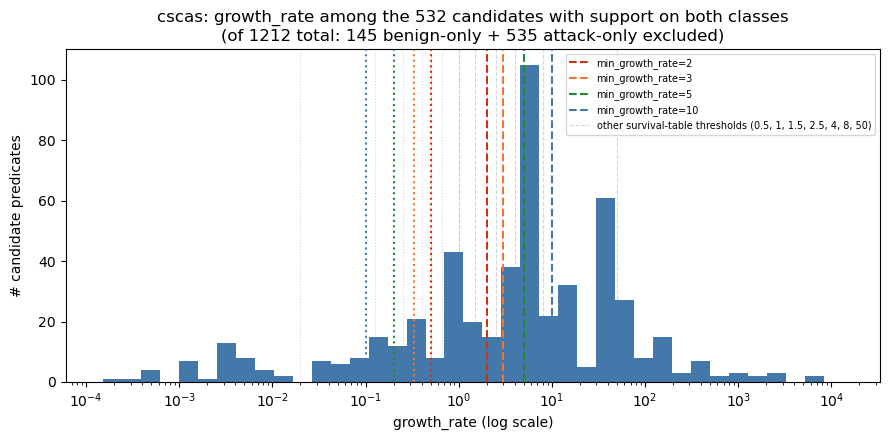

,threshold,n_attack_leaning,pct_attack_leaning,n_benign_leaning,pct_benign_leaning,n_kept_by_growth_rate,pct_kept_by_growth_rate
0,0.5,956,78.877888,328,27.062706,1212,100.000000
1,1.0,921,75.990099,291,24.009901,1212,100.000000
2,1.5,896,73.927393,262,21.617162,1158,95.544554
3,2.0,884,72.937294,256,21.122112,1140,94.059406
4,2.5,872,71.947195,255,21.039604,1127,92.986799
5,3.0,871,71.864686,239,19.719472,1110,91.584158
6,4.0,845,69.719472,234,19.306931,1079,89.026403
7,5.0,744,61.386139,223,18.399340,967,79.785479
8,8.0,727,59.983498,214,17.656766,941,77.640264
9,10.0,711,58.663366,207,17.079208,918,75.742574


In [50]:
CURRENT_THRESHOLDS = STEP1_GROWTH_RATES  # the growth_rate grid sweep_attribute_schema.py actually sweeps
SURVIVAL_THRESHOLDS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 8.0, 10.0, 50.0]  # finer grid for the table + figure below

# contrast_stats no longer contains "dead" candidates (compute_predicate_
# contrast_stats drops them upstream now), but growth_rate is still not a
# single homogeneous population: a candidate with confidence_attack=0 has
# growth_rate=0 exactly (benign-only), and one with confidence_benign=0 has
# growth_rate = confidence_attack/eps -- a huge but essentially arbitrary
# finite number (attack-only), an artifact of the +eps smoothing rather than
# a meaningful magnitude. Only candidates with support on BOTH classes have
# a growth_rate that's a genuinely comparable ratio, and only for that
# group can min_growth_rate's specific value (3 vs. 4 vs. 5) ever change
# the outcome -- benign-only/attack-only candidates trivially clear their
# respective direction regardless of which of {3,4,5} is picked.
ca = contrast_stats["confidence_attack"]
cb = contrast_stats["confidence_benign"]
gr = contrast_stats["growth_rate"]

benign_only = (ca == 0) & (cb > 0)
attack_only = (ca > 0) & (cb == 0)
both_nonzero = (ca > 0) & (cb > 0)
n_total = len(contrast_stats)

print(f"benign-only (attack support = 0):           {benign_only.sum()}/{n_total} ({benign_only.mean()*100:.1f}%)")
print(f"attack-only (benign support = 0):           {attack_only.sum()}/{n_total} ({attack_only.mean()*100:.1f}%)")
print(f"both nonzero (growth_rate is a real ratio): {both_nonzero.sum()}/{n_total} ({both_nonzero.mean()*100:.1f}%)")

gr_both = gr[both_nonzero]

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.logspace(np.log10(gr_both.min()), np.log10(gr_both.max()), 40)
ax.hist(gr_both, bins=bins, color="#4477AA")
ax.set_xscale("log")
ax.set_xlabel("growth_rate (log scale)")
ax.set_ylabel("# candidate predicates")
ax.set_title(
    f"cscas: growth_rate among the {both_nonzero.sum()} candidates with support on both classes\n"
    f"(of {n_total} total: {benign_only.sum()} benign-only + {attack_only.sum()} attack-only excluded)"
)

palette = ["#CC3311", "#EE7733", "#228833", "#4477AA", "#AA3377"]
for t, color in zip(CURRENT_THRESHOLDS, palette):
    attack_leaning = gr >= t
    benign_leaning = (cb > 0) & (gr <= 1.0 / t)
    pct_either = (attack_leaning | benign_leaning).mean() * 100
    ax.axvline(t, color=color, linestyle="--", linewidth=1.5,
               label=(f"min_growth_rate={t:g}"))
    ax.axvline(1.0 / t, color=color, linestyle=":", linewidth=1.5)

# Other thresholds from the finer SURVIVAL_THRESHOLDS grid below (not actually
# swept by sweep_attribute_schema.py) -- drawn as light reference lines so the
# real "elbow" is visible across the whole grid, not just {3,4,5}. One shared
# legend entry rather than one per line, to avoid drowning out the swept values.
_other_thresholds = [t for t in SURVIVAL_THRESHOLDS if t not in CURRENT_THRESHOLDS]
for t in _other_thresholds:
    ax.axvline(t, color=NEUTRAL_COLOR, linestyle="--", linewidth=0.8, alpha=0.6, zorder=0)
    ax.axvline(1.0 / t, color=NEUTRAL_COLOR, linestyle=":", linewidth=0.8, alpha=0.6, zorder=0)
ax.plot([], [], color=NEUTRAL_COLOR, linestyle="--", linewidth=0.8, alpha=0.6,
        label=f"other survival-table thresholds ({', '.join(f'{t:g}' for t in _other_thresholds)})")
ax.legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

# Finer-grained survival table, including thresholds well below the current
# grid, to see where the real "elbow" (the point candidate survival actually
# drops sharply) sits relative to {3.0, 4.0, 5.0} -- split by direction to
# match filter_contrast_survivors's either-side keep rule. Percentages are
# now of n_total (post dead-drop), not the old pre-fix 2933. Note this is
# growth_rate only; min_attack_coverage/min_benign_coverage gates aren't
# applied here. n_kept_by_growth_rate / pct_kept_by_growth_rate are the union
# of the attack-leaning and benign-leaning pools -- what the growth_rate gate
# alone would let through, before either coverage floor is applied.
survival = pd.DataFrame(
    [
        {
            "threshold": t,
            "n_attack_leaning": int((gr >= t).sum()),
            "pct_attack_leaning": (gr >= t).mean() * 100,
            "n_benign_leaning": int(((cb > 0) & (gr <= 1.0 / t)).sum()),
            "pct_benign_leaning": ((cb > 0) & (gr <= 1.0 / t)).mean() * 100,
            "n_kept_by_growth_rate": int(((gr >= t) | ((cb > 0) & (gr <= 1.0 / t))).sum()),
            "pct_kept_by_growth_rate": (((gr >= t) | ((cb > 0) & (gr <= 1.0 / t))).mean()) * 100,
        }
        for t in SURVIVAL_THRESHOLDS
    ]
)
survival


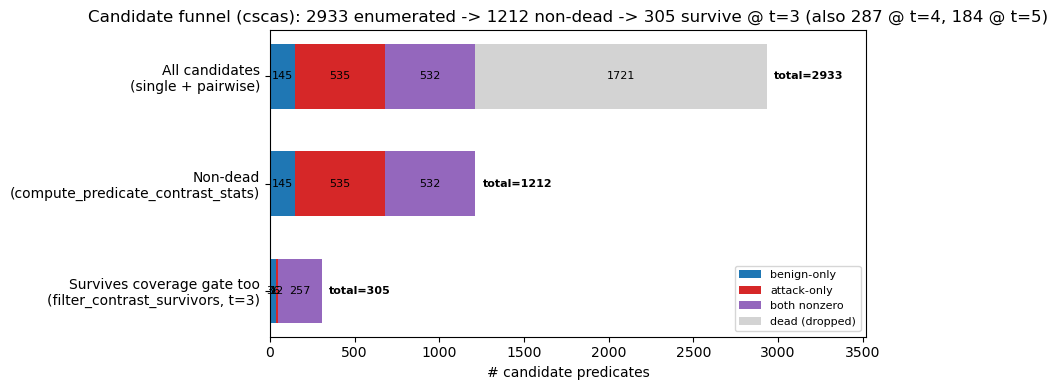

In [8]:
# Funnel: all enumerated single+pairwise candidates -> non-dead (dead
# dropped inside compute_predicate_contrast_stats itself) -> survives
# filter_contrast_survivors too (coverage gates + min_growth_rate). The
# Step-1 growth_rate anchor is the primary bar; other swept values are
# annotated in the title, since only the "both nonzero" segment's survivor
# count changes with the threshold (benign-only/attack-only survival is
# threshold-independent -- see the 2.1 histogram cell).
PRIMARY_THRESHOLD = STEP1_ANCHOR_GROWTH_RATE  # the sweep's benign-facing growth_rate anchor
survivors = filter_contrast_survivors(contrast_stats, min_growth_rate=PRIMARY_THRESHOLD)
surv_ca = survivors["confidence_attack"]
surv_cb = survivors["confidence_benign"]

stages = [
    ("All candidates\n(single + pairwise)", {
        "benign-only": int(benign_only.sum()),
        "attack-only": int(attack_only.sum()),
        "both nonzero": int(both_nonzero.sum()),
        "dead (dropped)": n_dead_dropped,
    }),
    ("Non-dead\n(compute_predicate_contrast_stats)", {
        "benign-only": int(benign_only.sum()),
        "attack-only": int(attack_only.sum()),
        "both nonzero": int(both_nonzero.sum()),
    }),
    (f"Survives coverage gate too\n(filter_contrast_survivors, t={PRIMARY_THRESHOLD:g})", {
        "benign-only": int(((surv_ca == 0) & (surv_cb > 0)).sum()),
        "attack-only": int(((surv_ca > 0) & (surv_cb == 0)).sum()),
        "both nonzero": int(((surv_ca > 0) & (surv_cb > 0)).sum()),
    }),
]

seg_colors = {
    "benign-only": "tab:blue",
    "attack-only": "tab:red",
    "both nonzero": "tab:purple",
    "dead (dropped)": "lightgrey",
}

fig, ax = plt.subplots(figsize=(9, 4))
for i, (label, segments) in enumerate(stages):
    y = len(stages) - 1 - i
    left = 0
    for seg_name, count in segments.items():
        ax.barh(y, count, left=left, color=seg_colors[seg_name], height=0.6,
                label=seg_name if i == 0 else None)
        if count > 0:
            ax.text(left + count / 2, y, f"{count}", ha="center", va="center", fontsize=8)
        left += count
    ax.text(left + n_candidates_total * 0.015, y, f"total={left}", va="center", fontsize=8, fontweight="bold")

ax.set_yticks([len(stages) - 1 - i for i in range(len(stages))])
ax.set_yticklabels([s[0] for s in stages])
ax.set_xlim(0, n_candidates_total * 1.2)
ax.set_xlabel("# candidate predicates")

n_survive_4 = len(filter_contrast_survivors(contrast_stats, min_growth_rate=4.0))
n_survive_5 = len(filter_contrast_survivors(contrast_stats, min_growth_rate=5.0))
ax.set_title(
    f"Candidate funnel (cscas): {n_candidates_total} enumerated -> {len(contrast_stats)} non-dead -> "
    f"{len(survivors)} survive @ t={PRIMARY_THRESHOLD:g} (also {n_survive_4} @ t=4, {n_survive_5} @ t=5)"
)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Reading this**: if the survival percentage barely moves between `min_growth_rate=3.0` and `5.0` in the table above, that's a direct, data-level explanation for `config_selection.ipynb`'s eta²≈0.0002 finding — the swept range doesn't select meaningfully different candidate sets, so it can't have moved the downstream model either. If instead survival drops sharply somewhere well below `3.0` (e.g. near `1.0`–`1.5`, the neutral point where a predicate stops being attack-indicative at all), that's the region actually worth screening -- both for a future revision of `screening_mining_settings.yaml`'s grid, and as the `min_growth_rate` value to hold fixed for the Step-2 sweeps (`sweep_attribute_schema.py`).

### 2.2 Coverage distribution

`min_attack_coverage` / `min_benign_coverage` (`ContrastSetFilterConfig`,
defaults `0.05` / `0.05`) are the other two Step-1 thresholds in
`filter_contrast_survivors`. Unlike `growth_rate` they have never been swept, so
there is no `parameter_importance` finding to check them against — this is the
same "does the default sit near a real elbow" look, with a different shape:

- **No benign-only / attack-only exemption.** `growth_rate` only discriminated
  within the "both nonzero" population; `_keep` checks
  `confidence_attack >= min_attack_coverage` for *any* attack-leaning candidate,
  attack-only ones included, so coverage prunes a much larger share of the pipeline.
- **Sequential, not independent.** `min_attack_coverage` is only checked once
  `attack_leaning` (`growth_rate >= min_growth_rate`) is already true — the
  population below is "candidates that passed `growth_rate` at the anchor
  threshold", not all of `contrast_stats`.
- **Separable by direction.** `attack_leaning` and `benign_leaning` are mutually
  exclusive, so the two coverage thresholds act on disjoint subpopulations and
  are swept as two independent 1-D problems.
- **`confidence_attack` / `confidence_benign` ARE the coverage metric** —
  `attack_support = n_fires_attack / n_attack` becomes `confidence_attack`
  verbatim. "confidence" and "coverage" are two names for one number here.
- **Class imbalance matters more than for `growth_rate`**, since it sets the
  coverage denominator directly.

**Confidence vs. coverage, concretely.** Three different per-candidate quantities get computed in `predicate_support_stats` / `compute_predicate_contrast_stats` (`thesis.mining.attribute_contrast_mining`), and it's easy to conflate them:

- **`confidence_attack` / `confidence_benign`** — per-class recall of the itemset:
  `attack_support = n_fires_attack / n_attack`, `benign_support = n_fires_benign / n_benign`
  i.e. *of all attack (resp. benign) alert-groups, what fraction does this itemset fire on.* Despite the name, this is **not** classical association-rule confidence (`P(class | itemset)`, a precision-like quantity) — that's never computed here. It's per-class coverage/recall, and as the bullet above says, it's the exact same field `min_attack_coverage`/`min_benign_coverage` filter on — "confidence" and "coverage" are two names for one number in this codebase, not two separate metrics.
- **`growth_rate`** — the ratio of the two: `attack_support / (benign_support + eps)`. This is what actually measures *discriminativeness* — how much more (or less) common the itemset is among attack groups vs. benign groups. `ca_pool`/`cb_pool` below restrict `confidence_attack`/`confidence_benign` to whichever side of the `growth_rate` gate they are on.
- **`support`** — `support_count / n_total`, the fraction of the *whole* population (attack + benign) that fires the itemset. The classical association-rule support: not class-conditional at all, don't confuse it with `confidence_attack`/`confidence_benign`.

- **`precision_attack`** (new, added to `compute_predicate_contrast_stats`'s output) — the classical association-rule confidence: `n_fires_attack / (n_fires_attack + n_fires_benign)` = `P(class=attack | itemset fires)`. This is the "if this rule fires, how trustworthy is the alert" number, and it is imbalance-sensitive by design (the huge benign population in this dataset drags it down even for attack-specific patterns) -- unlike `confidence_attack`/`growth_rate`, which normalize each class against its own size. It is diagnostic only: `filter_contrast_survivors` and the dynamic schema still gate on `growth_rate`/coverage, not on this.

In [9]:
ANCHOR_GROWTH_RATE = STEP1_ANCHOR_GROWTH_RATE  # the sweep's benign-facing growth_rate anchor (see 2.1)


attack_leaning = gr >= ANCHOR_GROWTH_RATE
benign_leaning = (cb > 0) & (gr <= 1.0 / ANCHOR_GROWTH_RATE)

ca_pool = ca[attack_leaning]  # confidence_attack among attack-leaning survivors of the growth_rate gate
cb_pool = cb[benign_leaning]  # confidence_benign among benign-leaning survivors of the growth_rate gate

n_attack_groups = int((y_ag == 1).sum())
n_benign_groups = int((y_ag == 0).sum())

# attack_only/benign_only/both_nonzero come from the 2.1 histogram cell -- attack_leaning is
# exactly attack_only (growth_rate is huge whenever confidence_benign == 0) plus whichever
# both_nonzero candidates clear the threshold, and symmetrically for benign_leaning.
n_attack_both = int((attack_leaning & both_nonzero).sum())
n_benign_both = int((benign_leaning & both_nonzero).sum())

print(f"attack-leaning pool ({attack_leaning.sum()}) = {attack_only.sum()} attack-only (all of them, automatically) "
      f"+ {n_attack_both} both-nonzero candidates with growth_rate >= {ANCHOR_GROWTH_RATE:g}")
print(f"benign-leaning pool ({benign_leaning.sum()}) = {benign_only.sum()} benign-only (all of them, automatically) "
      f"+ {n_benign_both} both-nonzero candidates with growth_rate <= {1.0 / ANCHOR_GROWTH_RATE:.3g}")
print()
print(f"dataset-wide attack alert-groups: {n_attack_groups:,}")
print(f"dataset-wide benign alert-groups: {n_benign_groups:,}")
print(f"imbalance: 1 attack : {n_benign_groups / n_attack_groups:.1f} benign")


attack-leaning pool (871) = 535 attack-only (all of them, automatically) + 336 both-nonzero candidates with growth_rate >= 3
benign-leaning pool (239) = 145 benign-only (all of them, automatically) + 94 both-nonzero candidates with growth_rate <= 0.333

dataset-wide attack alert-groups: 20,952
dataset-wide benign alert-groups: 1,374,372
imbalance: 1 attack : 65.6 benign


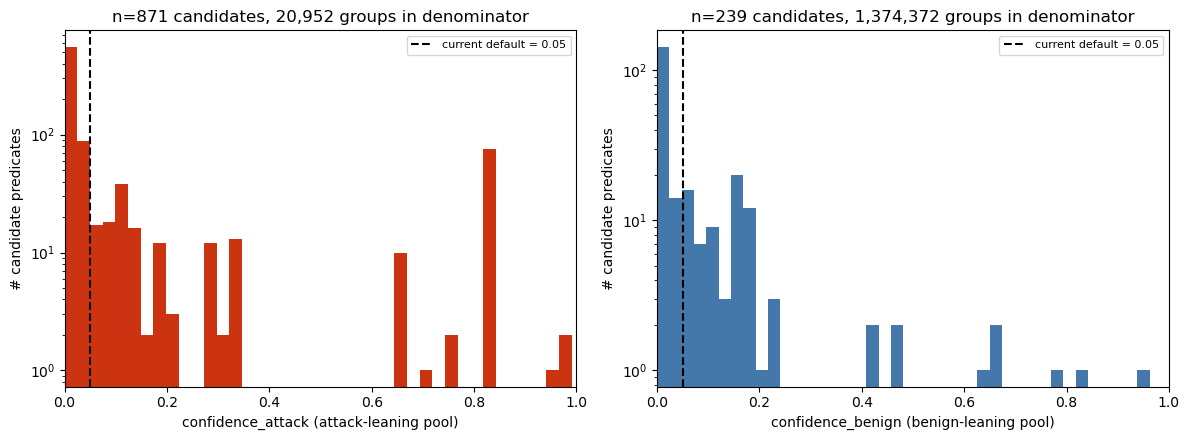

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, pool, label, color, n_groups in [
    (axes[0], ca_pool, "confidence_attack (attack-leaning pool)", "#CC3311", n_attack_groups),
    (axes[1], cb_pool, "confidence_benign (benign-leaning pool)", "#4477AA", n_benign_groups),
]:
    ax.hist(pool, bins=40, color=color)
    ax.axvline(0.05, color="black", linestyle="--", linewidth=1.5, label="current default = 0.05")
    ax.set_xlabel(label)
    ax.set_ylabel("# candidate predicates")
    ax.set_xlim(0, 1)
    ax.set_title(f"n={len(pool)} candidates, {n_groups:,} groups in denominator")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Reading the table below**: `n_attack_groups`/`n_benign_groups` (the
coverage denominators) are both large (20,952 / 1,374,372), so granularity
of the coverage metric itself isn't the bottleneck here -- unlike a small
dataset where coverage could only take values that are multiples of
`1/n_groups`. The actual noise source is pool *size*: the benign-leaning
pool has far fewer candidates than the attack-leaning one, so
`pct_benign_survive` is expected to step more coarsely/noisily than
`pct_attack_survive`. Don't over-read fine "elbows" on the benign side with
only a few hundred candidates behind each percentage.


In [11]:
COVERAGE_GRID = [0.0, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]

coverage_survival = pd.DataFrame(
    [
        {
            "threshold": t,
            "n_attack_survive": int((ca_pool >= t).sum()),
            "pct_attack_survive": (ca_pool >= t).mean() * 100,
            "n_benign_survive": int((cb_pool >= t).sum()),
            "pct_benign_survive": (cb_pool >= t).mean() * 100,
        }
        for t in COVERAGE_GRID
    ]
)
coverage_survival


,threshold,n_attack_survive,pct_attack_survive,n_benign_survive,pct_benign_survive
0,0.00,871,100.000000,239,100.000000
1,0.01,346,39.724455,114,47.698745
2,0.02,337,38.691160,95,39.748954
3,0.03,309,35.476464,93,38.912134
4,0.05,224,25.717566,81,33.891213
5,0.08,206,23.650976,65,27.196653
6,0.10,189,21.699196,50,20.920502
7,0.15,134,15.384615,45,18.828452
8,0.20,121,13.892078,13,5.439331
9,0.30,106,12.169920,10,4.184100


### 2.3 Joint growth_rate × coverage survival grid

Closing §2.1 and §2.2 by looking at both Step-1 axes together instead of one
fixed default against the other. `GROWTH_RATE_GRID` spans well below the swept
region (down to the neutral point at 1.0) and well above it; `COVERAGE_GRID` is
the same grid as §2.2. Both the current shipped defaults (`growth_rate=3.0`,
coverage `0.05`) and any future revision can be read off one joint view.

In [12]:
# Joint sweep: full min_growth_rate x coverage grid, closing out the growth_rate
# (2.1) and coverage (2.2) analyses above by looking at both
# axes together instead of one fixed default against the other. Supersedes
# the narrower CURRENT_THRESHOLDS x 0.05 check this cell used to run --
# COVERAGE_GRID is the same grid defined in 2.2; GROWTH_RATE_GRID is new and
# spans well below the swept {3,4,5} region (down to the neutral point at
# 1.0) and well above it, so both grids can be picked from one joint view.
from IPython.display import display

GROWTH_RATE_GRID = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 8.0, 10.0, 50.0]

interaction_rows = []
for t in GROWTH_RATE_GRID:
    al = gr >= t
    bl = (cb > 0) & (gr <= 1.0 / t)
    ca_t = ca[al]
    cb_t = cb[bl]
    for c in COVERAGE_GRID:
        interaction_rows.append(
            {
                "min_growth_rate": t,
                "coverage_threshold": c,
                "n_attack_pool": int(al.sum()),
                "n_benign_pool": int(bl.sum()),
                "n_attack_survive": int((ca_t >= c).sum()),
                "pct_attack_survive": (ca_t >= c).mean() * 100,
                "n_benign_survive": int((cb_t >= c).sum()),
                "pct_benign_survive": (cb_t >= c).mean() * 100,
            }
        )

interaction_grid = pd.DataFrame(interaction_rows)

# Pivoted views easier to spot a joint elbow across both parameters than
# the 176-row long form above: rows = min_growth_rate, columns =
# coverage_threshold, cells = % of that growth_rate pool surviving that
# coverage cut.
attack_survival_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="pct_attack_survive"
).round(1)
benign_survival_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="pct_benign_survive"
).round(1)

print("% of attack-leaning pool surviving min_attack_coverage (rows=min_growth_rate, cols=min_attack_coverage):")
display(attack_survival_grid)
print()
print("% of benign-leaning pool surviving min_benign_coverage (rows=min_growth_rate, cols=min_benign_coverage):")
display(benign_survival_grid)

% of attack-leaning pool surviving min_attack_coverage (rows=min_growth_rate, cols=min_attack_coverage):


coverage_threshold,0.00,0.01,0.02,0.03,0.05,0.08,0.10,0.15,0.20,0.30,0.50,0.75,0.90,0.95,0.99,1.00
min_growth_rate,,,,,,,,,,,,,,,,
0.5,100.0,42.7,41.0,36.9,26.6,23.2,21.2,15.4,12.8,11.2,9.5,8.2,0.3,0.3,0.1,0.0
1.0,100.0,41.0,39.8,36.8,27.5,24.1,22.0,16.0,13.2,11.6,9.9,8.5,0.3,0.3,0.1,0.0
1.5,100.0,40.4,39.4,36.3,26.7,24.6,22.4,16.3,13.6,11.9,10.2,8.7,0.3,0.3,0.1,0.0
2.0,100.0,40.5,39.5,36.3,26.7,24.7,22.6,16.4,13.7,12.0,10.3,8.8,0.3,0.3,0.1,0.0
2.5,100.0,39.8,38.8,35.6,25.8,23.7,21.7,15.4,13.9,12.2,10.4,8.9,0.3,0.3,0.1,0.0
3.0,100.0,39.7,38.7,35.5,25.7,23.7,21.7,15.4,13.9,12.2,10.4,9.0,0.3,0.3,0.1,0.0
4.0,100.0,39.2,38.1,34.9,25.0,24.3,22.2,15.9,14.3,12.5,10.8,9.2,0.4,0.4,0.1,0.0
5.0,100.0,30.9,29.8,26.2,14.9,14.2,13.4,6.2,5.8,3.8,3.4,1.7,0.4,0.4,0.1,0.0
8.0,100.0,29.3,28.2,24.6,13.1,12.4,11.6,5.6,5.5,3.7,3.3,1.7,0.3,0.3,0.1,0.0



% of benign-leaning pool surviving min_benign_coverage (rows=min_growth_rate, cols=min_benign_coverage):


coverage_threshold,0.00,0.01,0.02,0.03,0.05,0.08,0.10,0.15,0.20,0.30,0.50,0.75,0.90,0.95,0.99,1.00
min_growth_rate,,,,,,,,,,,,,,,,
0.5,100.0,54.3,46.3,45.4,37.8,21.3,16.5,14.3,4.0,3.0,1.8,0.9,0.3,0.3,0.0,0.0
1.0,100.0,54.6,46.4,45.4,37.1,23.0,17.5,15.5,4.5,3.4,2.1,1.0,0.3,0.3,0.0,0.0
1.5,100.0,50.4,42.4,41.6,36.6,25.6,19.5,17.2,5.0,3.8,2.3,1.1,0.4,0.4,0.0,0.0
2.0,100.0,49.6,42.2,41.4,36.7,25.8,19.5,17.6,5.1,3.9,2.3,1.2,0.4,0.4,0.0,0.0
2.5,100.0,49.4,42.0,41.2,36.5,25.5,19.6,17.6,5.1,3.9,2.4,1.2,0.4,0.4,0.0,0.0
3.0,100.0,47.7,39.7,38.9,33.9,27.2,20.9,18.8,5.4,4.2,2.5,1.3,0.4,0.4,0.0,0.0
4.0,100.0,46.6,38.5,37.6,32.5,26.9,20.5,18.4,5.1,4.3,2.6,1.3,0.4,0.4,0.0,0.0
5.0,100.0,47.1,39.0,38.1,32.7,26.9,21.1,19.3,5.4,4.5,2.7,1.3,0.4,0.4,0.0,0.0
8.0,100.0,46.7,38.8,37.9,32.2,27.1,21.0,19.6,5.1,4.2,2.3,1.4,0.5,0.5,0.0,0.0


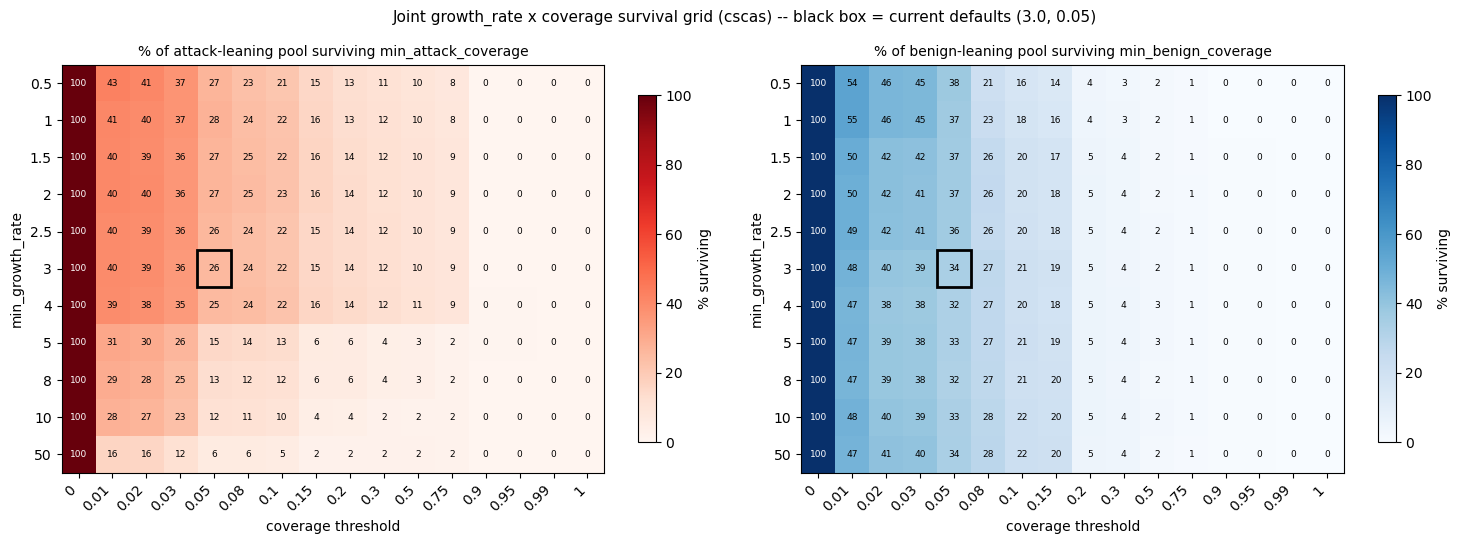

In [13]:
# Heatmap version of the candidate funnel's final "survives" stage, across
# the full (min_growth_rate, coverage) grid from the joint sweep above --
# extends the 2.1 funnel plot's single-threshold bar to the whole grid,
# without trying to draw 176 separate 3-segment funnels. Sequential single-hue
# ramps (red/blue), matching this notebook's existing attack=red / benign=blue
# convention (funnel plot and 2.2 histograms above) rather than a
# rainbow colormap.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

heatmap_specs = [
    (axes[0], attack_survival_grid, "Reds", "% of attack-leaning pool surviving min_attack_coverage"),
    (axes[1], benign_survival_grid, "Blues", "% of benign-leaning pool surviving min_benign_coverage"),
]

for ax, grid, cmap, title in heatmap_specs:
    im = ax.imshow(grid.to_numpy(), cmap=cmap, vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([f"{c:g}" for c in grid.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([f"{r:g}" for r in grid.index])
    ax.set_xlabel("coverage threshold")
    ax.set_ylabel("min_growth_rate")
    ax.set_title(title, fontsize=10)

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid.iat[i, j]
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6.5,
                     color="white" if val > 55 else "black")

    # Current shipped defaults (ContrastSetFilterConfig / screening_mining_settings.yaml):
    # min_growth_rate=3.0, min_attack_coverage=min_benign_coverage=0.05
    if 3.0 in grid.index and 0.05 in grid.columns:
        gi = list(grid.index).index(3.0)
        gj = list(grid.columns).index(0.05)
        ax.add_patch(plt.Rectangle((gj - 0.5, gi - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    fig.colorbar(im, ax=ax, label="% surviving", shrink=0.85)

fig.suptitle("Joint growth_rate x coverage survival grid (cscas) -- black box = current defaults (3.0, 0.05)", fontsize=11)
plt.tight_layout()
plt.show()

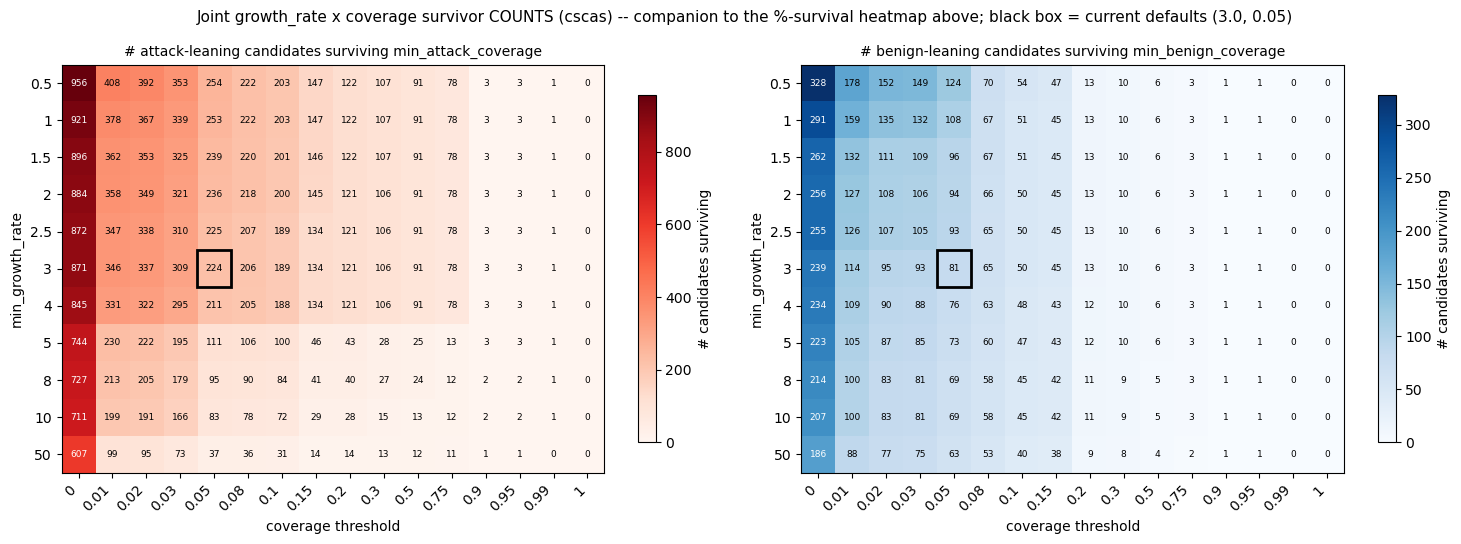

In [14]:
# Raw-count companion to the %-survival heatmap above. growth_rate's effect
# on pool *size* is real, it's just invisible in a percentage table once
# coverage_threshold=0 is a no-op filter -- every row there reads 100%
# regardless of growth_rate, because each percentage is relative to that
# row's own already-shrunk pool (attack_leaning = gr >= t), not a fixed
# universe of candidates. This plots the raw n_attack_survive/n_benign_survive
# counts instead, where growth_rate's shrinkage of the pool is directly
# visible (unlike the %-heatmap, each panel gets its own color scale here --
# raw counts aren't naturally comparable 0..100 the way percentages are).
n_attack_survive_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="n_attack_survive"
)
n_benign_survive_grid = interaction_grid.pivot(
    index="min_growth_rate", columns="coverage_threshold", values="n_benign_survive"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

count_heatmap_specs = [
    (axes[0], n_attack_survive_grid, "Reds", "# attack-leaning candidates surviving min_attack_coverage"),
    (axes[1], n_benign_survive_grid, "Blues", "# benign-leaning candidates surviving min_benign_coverage"),
]

for ax, grid, cmap, title in count_heatmap_specs:
    vmax = int(grid.to_numpy().max())
    im = ax.imshow(grid.to_numpy(), cmap=cmap, vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([f"{c:g}" for c in grid.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([f"{r:g}" for r in grid.index])
    ax.set_xlabel("coverage threshold")
    ax.set_ylabel("min_growth_rate")
    ax.set_title(title, fontsize=10)

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = int(grid.iat[i, j])
            ax.text(j, i, f"{val:d}", ha="center", va="center", fontsize=6.5,
                     color="white" if val > vmax * 0.55 else "black")

    # Current shipped defaults (ContrastSetFilterConfig / screening_mining_settings.yaml):
    # min_growth_rate=3.0, min_attack_coverage=min_benign_coverage=0.05
    if 3.0 in grid.index and 0.05 in grid.columns:
        gi = list(grid.index).index(3.0)
        gj = list(grid.columns).index(0.05)
        ax.add_patch(plt.Rectangle((gj - 0.5, gi - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

    fig.colorbar(im, ax=ax, label="# candidates surviving", shrink=0.85)

fig.suptitle("Joint growth_rate x coverage survivor COUNTS (cscas) -- companion to the %-survival heatmap "
             "above; black box = current defaults (3.0, 0.05)", fontsize=11)
plt.tight_layout()
plt.show()

### 2.4 Within-Step-1 independence: are the four thresholds separable?

`filter_contrast_survivors` applies, per candidate, a **direction gate** then the
matching **coverage floor**:

1. *attack-leaning* if `growth_rate >= min_growth_rate_attack` (which falls back
   to `min_growth_rate` when unset); *benign-leaning* if `confidence_benign > 0`
   and `growth_rate <= 1 / min_growth_rate`;
2. then `confidence_attack >= min_attack_coverage` (attack-leaning) **or**
   `confidence_benign >= min_benign_coverage` (benign-leaning).

For `min_growth_rate >= 1` the two directions are **mutually exclusive**
(`gr >= t` and `gr <= 1/t` cannot both hold), so the four thresholds split into
an attack-side pair and a benign-side pair. The cell below checks each claim
directly on the real function:

- **`min_attack_coverage` ⟂ `min_benign_coverage`** — they gate disjoint
  candidate sets, so one cannot move the other's survivors.
- **`min_growth_rate_attack` ⟂ the benign side** — it only re-gates the attack
  direction; the benign-leaning survivor set must be byte-identical across it.
- **`min_growth_rate` ⟂ the attack side, once `min_growth_rate_attack` is set** —
  the attack-leaning survivor set must then be byte-identical across
  `min_growth_rate`.
- **The one real coupling** is by design: each direction gate runs *before* its
  coverage floor, so `min_growth_rate` / `min_growth_rate_attack` change *which
  pool* the coverage floor then sees — sequential, not independent, and exactly
  what §2.3's joint grid characterises.

(0) attack-leaning / benign-leaning candidate sets are disjoint at every min_growth_rate in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 8.0, 10.0, 50.0]
(1) attack-survivor count spread across min_benign_coverage: 0  (expect 0)
    benign-survivor count spread across min_attack_coverage: 0  (expect 0)
(2) benign-leaning survivor set byte-identical across min_growth_rate_attack [None, 2.0, 5.0, 10.0]: 81 itemsets
(3) attack-leaning survivor set byte-identical across min_growth_rate [2.0, 3.0, 5.0, 10.0] when min_growth_rate_attack=2: 236 itemsets
  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_step1_coverage_independence.png


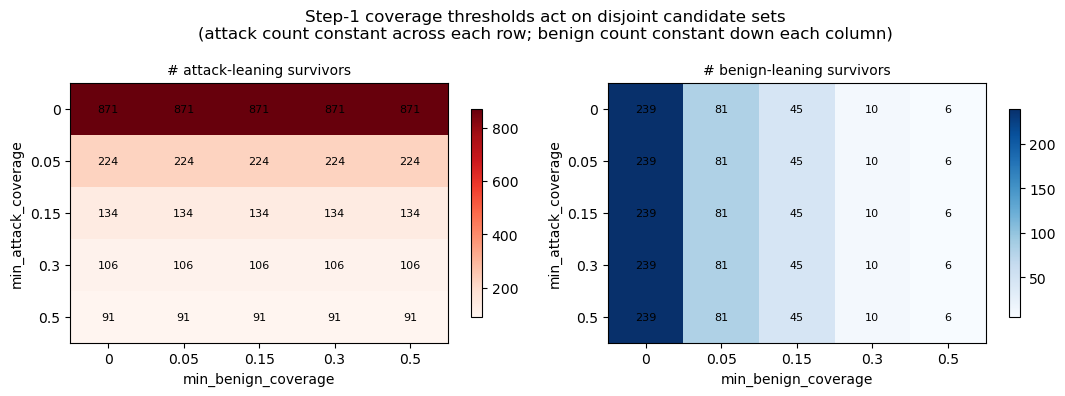

In [15]:
from itertools import product


def survivor_itemsets(gr_=None, gra_=None, ac=None, bc=None):
    """(attack-leaning, benign-leaning) survivor itemset sets for one threshold combo."""
    gr_ = STEP1_ANCHOR_GROWTH_RATE if gr_ is None else gr_
    ac = STEP1_ANCHOR_ATTACK_COVERAGE if ac is None else ac
    bc = STEP1_ANCHOR_BENIGN_COVERAGE if bc is None else bc
    s = filter_contrast_survivors(
        contrast_stats, min_growth_rate=gr_, min_growth_rate_attack=gra_,
        min_attack_coverage=ac, min_benign_coverage=bc,
    )
    at_thr = gr_ if gra_ is None else gra_
    attack = frozenset(tuple(i) for i, g in zip(s["itemset"], s["growth_rate"]) if g >= at_thr)
    benign = frozenset(tuple(i) for i in s["itemset"]) - attack
    return attack, benign


# (0) the two direction gates are mutually exclusive for every real min_growth_rate
#     (>= 1; a ratio threshold < 1 is never used and would make the gates overlap).
_real_gr = [t for t in GROWTH_RATE_GRID if t >= 1.0]
for t in _real_gr:
    assert not ((gr >= t) & (cb > 0) & (gr <= 1.0 / t)).any(), f"gate overlap at min_growth_rate={t}"
print(f"(0) attack-leaning / benign-leaning candidate sets are disjoint at every min_growth_rate in {_real_gr}")

# (1) min_attack_coverage vs min_benign_coverage -- full grid, each moves only its own side
COV_GRID = sorted({0.0, 0.05, 0.15, 0.30, 0.5})
rows = []
for ac, bc in product(COV_GRID, COV_GRID):
    at, be = survivor_itemsets(ac=ac, bc=bc)
    rows.append({"min_attack_coverage": ac, "min_benign_coverage": bc,
                 "n_attack_survivors": len(at), "n_benign_survivors": len(be)})
cov_indep = pd.DataFrame(rows)
n_attack_grid = cov_indep.pivot(index="min_attack_coverage", columns="min_benign_coverage", values="n_attack_survivors")
n_benign_grid = cov_indep.pivot(index="min_attack_coverage", columns="min_benign_coverage", values="n_benign_survivors")
spread_attack = float(n_attack_grid.max(axis=1).sub(n_attack_grid.min(axis=1)).max())  # across bc, per ac
spread_benign = float(n_benign_grid.max(axis=0).sub(n_benign_grid.min(axis=0)).max())  # across ac, per bc
print(f"(1) attack-survivor count spread across min_benign_coverage: {spread_attack:g}  (expect 0)")
print(f"    benign-survivor count spread across min_attack_coverage: {spread_benign:g}  (expect 0)")
assert spread_attack == 0 and spread_benign == 0, "coverage thresholds are NOT separable -- investigate"

# (2) min_growth_rate_attack leaves the benign-leaning survivor set unchanged
benign_by_gra = {gra: survivor_itemsets(gra_=gra)[1] for gra in [None, *GROWTH_RATES_ATTACK]}
assert len(set(benign_by_gra.values())) == 1, "min_growth_rate_attack moved a benign survivor"
print(f"(2) benign-leaning survivor set byte-identical across min_growth_rate_attack "
      f"{list(benign_by_gra)}: {len(next(iter(benign_by_gra.values())))} itemsets")

# (3) with min_growth_rate_attack set, min_growth_rate no longer touches the attack side
_gra = GROWTH_RATES_ATTACK[0]
attack_by_gr = {g: survivor_itemsets(gr_=g, gra_=_gra)[0] for g in GROWTH_RATES}
assert len(set(attack_by_gr.values())) == 1, "min_growth_rate still moves the attack side when mgra is set"
print(f"(3) attack-leaning survivor set byte-identical across min_growth_rate {GROWTH_RATES} "
      f"when min_growth_rate_attack={_gra:g}: {len(next(iter(attack_by_gr.values())))} itemsets")

# visual: each coverage threshold moves only its own side's survivor count
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, grid, cmap, title in [
    (axes[0], n_attack_grid, "Reds", "# attack-leaning survivors"),
    (axes[1], n_benign_grid, "Blues", "# benign-leaning survivors"),
]:
    im = ax.imshow(grid.to_numpy(), cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(grid.columns))); ax.set_xticklabels([f"{c:g}" for c in grid.columns])
    ax.set_yticks(range(len(grid.index))); ax.set_yticklabels([f"{r:g}" for r in grid.index])
    ax.set_xlabel("min_benign_coverage"); ax.set_ylabel("min_attack_coverage")
    ax.set_title(title, fontsize=10)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{int(grid.iat[i, j])}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("Step-1 coverage thresholds act on disjoint candidate sets\n"
             "(attack count constant across each row; benign count constant down each column)")
fig.tight_layout()
savefig(fig, "grid_step1_coverage_independence.png")
plt.show()

**Result**: all three separability claims hold exactly.

- **Coverage thresholds are separable** — measured, not just argued from "disjoint
  subpopulations": the attack-leaning survivor count is invariant to
  `min_benign_coverage` (constant along every row) and the benign-leaning count
  invariant to `min_attack_coverage` (constant down every column), spread `0`
  both ways. At the anchor (`0.05` / `0.05`): 224 attack-leaning + 81
  benign-leaning survivors. Coverage is by far the largest Step-1 filter —
  871 → 224 attack-leaning candidates as `min_attack_coverage` goes 0 → 0.05.
- **`min_growth_rate_attack` ⟂ the benign side**: benign-leaning survivor set
  byte-identical (81 itemsets) across `min_growth_rate_attack ∈ {None, 2, 5, 10}`.
- **`min_growth_rate` ⟂ the attack side once `min_growth_rate_attack` is set**:
  attack-leaning survivor set byte-identical (236 itemsets) across
  `min_growth_rate ∈ {2, 3, 5, 10}` at `min_growth_rate_attack = 2`.

So within Step 1 the only coupling is the intended one — each direction gate
feeds its own coverage floor. The four thresholds reduce to two independent
`(growth-rate, coverage)` pairs, one per class direction; the one-axis-at-a-time
sweeps in §4 are valid within Step 1.

## 3. Orthogonality: does the two-tree redesign actually decouple things?

Everything from section 4 onward reads one axis's own sweep in isolation and treats
every other axis as noise -- that's only valid if the axes genuinely don't interact.
This section checks it, rather than assuming it: `growth_rate`/coverage (Step 1)
against both tree depths, and the two tree depths (`max_depth`, `max_depth_attack`)
against each other, which is the interaction the whole two-tree redesign exists to
break.

### 3.1 growth_rate: still a pure Step-1 lever

`growth_rate` was swept alone at the Step-2 anchor (`max_depth=1`,
`max_depth_attack=3`) -- if it's still true that growth_rate has zero effect on Step 2
under two-tree fitting, `mean_tree_precision_attack` and `mean_tree_recall_benign`
should be flat across every growth_rate value while `n_features` (driven by Step-1
survivor count) varies.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_growth_rate_orthogonality.png


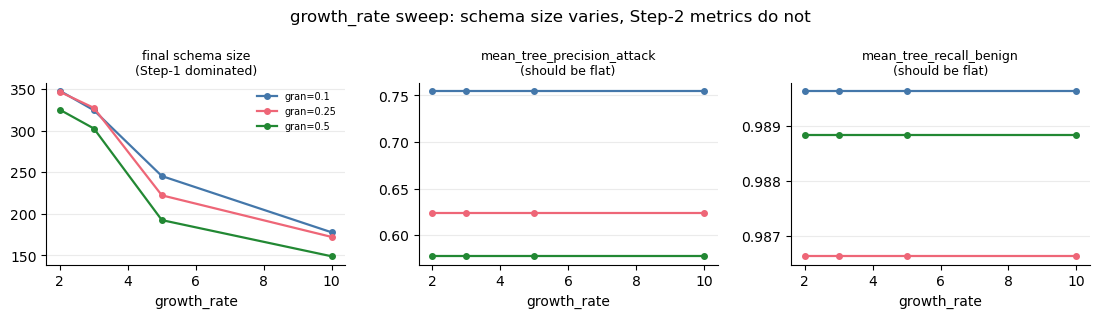

,n_features,mean_tree_precision_attack,mean_tree_recall_benign
growth_rate,,,
2.0,344.625,0.7,0.989
3.0,322.375,0.7,0.989
5.0,233.000,0.7,0.989
10.0,172.812,0.7,0.989


In [16]:
axis_effect_fig(
    grid_df[GROWTH_RATE_SWEEP_MASK], "growth_rate",
    [("n_features", "final schema size\n(Step-1 dominated)"),
     ("mean_tree_precision_attack", "mean_tree_precision_attack\n(should be flat)"),
     ("mean_tree_recall_benign", "mean_tree_recall_benign\n(should be flat)")],
    per_gran=True,
    title="growth_rate sweep: schema size varies, Step-2 metrics do not",
    figname="grid_growth_rate_orthogonality.png",
)

### 3.2 max_depth vs. max_depth_attack: independent by construction, confirmed

Each depth axis was swept alone, holding the other tree's depth at its anchor. If the
two trees really are independent, `max_depth`'s sweep should move
`mean_tree_recall_benign` while leaving `mean_tree_precision_attack` untouched (it
wasn't even the tree being varied), and vice versa for `max_depth_attack`.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_two_tree_sweeps.png


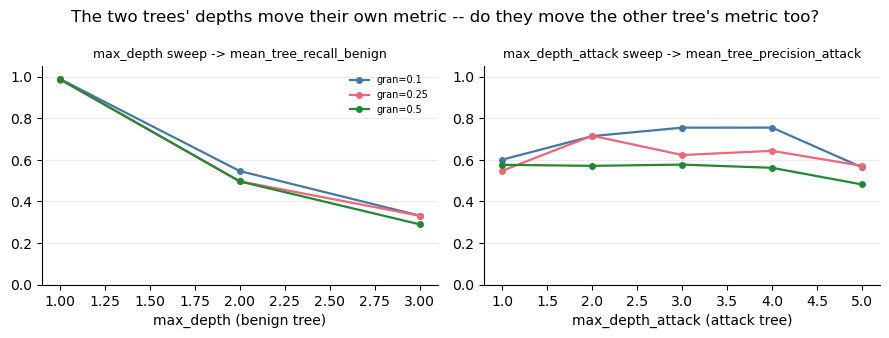

max_depth sweep -- does it also move mean_tree_precision_attack (should be flat, it's the OTHER tree)?
           mean_tree_recall_benign  mean_tree_precision_attack
max_depth                                                     
1                            0.989                         0.7
2                            0.528                         0.7
3                            0.326                         0.7

max_depth_attack sweep -- does it also move mean_tree_recall_benign (should be flat, it's the OTHER tree)?
                  mean_tree_precision_attack  mean_tree_recall_benign
max_depth_attack                                                     
1                                      0.585                    0.989
2                                      0.697                    0.989
3                                      0.700                    0.989
4                                      0.703                    0.989
5                                      0.555          

In [17]:
md_sweep = grid_df[MAX_DEPTH_SWEEP_MASK]
mda_sweep = grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
ax = axes[0]
for gran in GRANULARITIES:
    s = md_sweep[md_sweep.gran == gran].groupby("max_depth")["mean_tree_recall_benign"].mean()
    ax.plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
ax.set_title("max_depth sweep -> mean_tree_recall_benign", fontsize=9)
ax.set_xlabel("max_depth (benign tree)")
ax.set_ylim(0, 1.05)
strip_axes(ax)
ax.legend(frameon=False, fontsize=7)

ax = axes[1]
for gran in GRANULARITIES:
    s = mda_sweep[mda_sweep.gran == gran].groupby("max_depth_attack")["mean_tree_precision_attack"].mean()
    ax.plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
ax.set_title("max_depth_attack sweep -> mean_tree_precision_attack", fontsize=9)
ax.set_xlabel("max_depth_attack (attack tree)")
ax.set_ylim(0, 1.05)
strip_axes(ax)

fig.suptitle("The two trees' depths move their own metric -- do they move the other tree's metric too?")
fig.tight_layout()
savefig(fig, "grid_two_tree_sweeps.png")
plt.show()

print("max_depth sweep -- does it also move mean_tree_precision_attack (should be flat, it's the OTHER tree)?")
display_df = md_sweep.groupby("max_depth")[["mean_tree_recall_benign", "mean_tree_precision_attack"]].mean().round(3)
print(display_df)
print()
print("max_depth_attack sweep -- does it also move mean_tree_recall_benign (should be flat, it's the OTHER tree)?")
display_df2 = mda_sweep.groupby("max_depth_attack")[["mean_tree_precision_attack", "mean_tree_recall_benign"]].mean().round(3)
print(display_df2)


### 3.3 Cross-check: growth_rate x max_depth_attack jointly

A small, deliberately-kept cross-check (`growth_rate` in {2.0, 10.0} x
`max_depth_attack` in {1, 5}, `max_depth` held at its anchor) -- unlike the
single-tree script's later revision, which dropped its cross-check as redundant with
an already-exhaustively-verified grid, this one script keeps it because the algorithm
itself changed and the orthogonality argument hadn't been re-verified under two-tree
fitting before this run.

In [18]:
cross_check = grid_df[CROSS_CHECK_MASK]
cc_table = (
    cross_check.groupby(["growth_rate", "max_depth_attack"])[
        ["mean_tree_precision_attack", "mean_tree_recall_benign", "n_features"]
    ].mean().round(3)
)
print(cc_table)
print()
# Precision/recall should be identical across growth_rate at a fixed max_depth_attack
# (only n_features, the Step-1-driven schema size, should differ) -- if the growth_rate=2.0
# and growth_rate=10.0 rows disagree on precision/recall within a max_depth_attack
# level, that IS a real interaction and everything above needs revisiting.
precision_spread = cc_table.groupby("max_depth_attack")["mean_tree_precision_attack"].agg(lambda s: s.max() - s.min())
recall_spread = cc_table.groupby("max_depth_attack")["mean_tree_recall_benign"].agg(lambda s: s.max() - s.min())
print(f"Max precision_attack spread across growth_rate, per max_depth_attack: {precision_spread.max():.4f}")
print(f"Max recall_benign spread across growth_rate, per max_depth_attack: {recall_spread.max():.4f}")
assert precision_spread.max() < 0.01 and recall_spread.max() < 0.01, (
    "growth_rate x max_depth_attack interaction detected -- do not trust the "
    "one-axis-at-a-time sweeps above without investigating this"
)
print("Confirmed: growth_rate has no detectable effect on either Step-2 metric, even jointly with max_depth_attack.")


                              mean_tree_precision_attack  mean_tree_recall_benign  n_features
growth_rate max_depth_attack                                                                 
2.0         1                                      0.585                    0.989     344.250
            5                                      0.555                    0.989     345.625
10.0        1                                      0.585                    0.989     172.438
            5                                      0.555                    0.989     173.812

Max precision_attack spread across growth_rate, per max_depth_attack: 0.0000
Max recall_benign spread across growth_rate, per max_depth_attack: 0.0000
Confirmed: growth_rate has no detectable effect on either Step-2 metric, even jointly with max_depth_attack.


### 3.4 Temporal stability: how much does each swept axis's schema drift across windows?

Consecutive-window Jaccard similarity (win 0 vs 1, win 1 vs 2, ...), separately for
Step 1 (attack-leaning and benign-leaning contrast itemsets, from the `growth_rate`
sweep) and each Step-2 tree (benign tree's base features from the `max_depth` sweep,
attack tree's from the `max_depth_attack` sweep) -- each read at its own anchor point
for the other axes, same masks as section 3.1/3.2. `gran=0.5` has only one window
(nothing to compare it to) and is excluded.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_temporal_stability.png


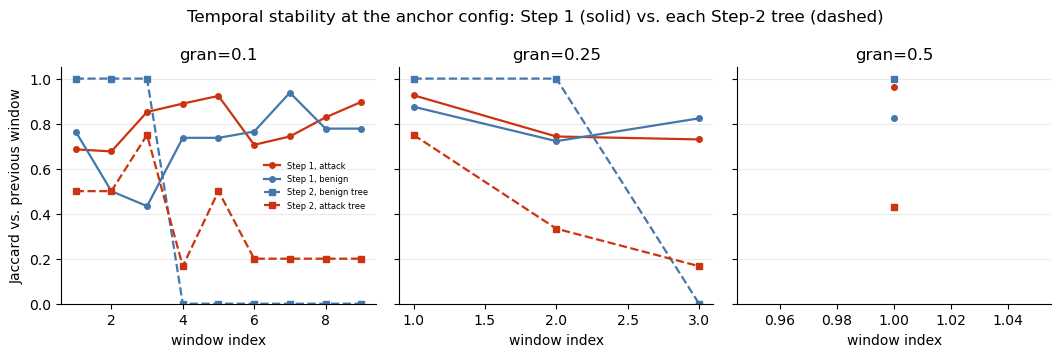

Mean consecutive-window Jaccard:
Step 1, attack: 0.812
Step 1, benign: 0.744
Step 2, benign tree: 0.462
Step 2, attack tree: 0.377


In [19]:
def jaccard(a: frozenset, b: frozenset) -> float:
    return len(a & b) / len(a | b) if (a or b) else 1.0


def consecutive_window_jaccard(df: pd.DataFrame, group_cols: list[str], set_cols: dict[str, str]) -> pd.DataFrame:
    """set_cols: {output_col_name: source_column_with_frozensets}. One row per
    (group, window, set_col) with that window's Jaccard vs. the previous window."""
    rows = []
    for key, sub in df.groupby(group_cols):
        sub = sub.sort_values("win_idx")
        prev = {}
        prev_win = None
        for _, r in sub.iterrows():
            if prev_win is not None:
                row = dict(zip(group_cols, key if isinstance(key, tuple) else (key,)))
                row["win_idx"] = r["win_idx"]
                for out_col, src_col in set_cols.items():
                    row[out_col] = jaccard(r[src_col], prev[src_col])
                rows.append(row)
            prev = {src_col: r[src_col] for src_col in set_cols.values()}
            prev_win = r["win_idx"]
    return pd.DataFrame(rows)


grans_with_multiple_windows = [g for g in GRANULARITIES if grid_df[grid_df.gran == g]["win_idx"].nunique() > 1]

step1_stability = consecutive_window_jaccard(
    grid_df[GROWTH_RATE_SWEEP_MASK & grid_df.gran.isin(grans_with_multiple_windows)],
    ["growth_rate", "gran"],
    {"jaccard_attack": "_contrast_itemset_set_attack", "jaccard_benign": "_contrast_itemset_set_benign"},
)
benign_tree_stability = consecutive_window_jaccard(
    grid_df[MAX_DEPTH_SWEEP_MASK & grid_df.gran.isin(grans_with_multiple_windows)],
    ["max_depth", "gran"],
    {"jaccard": "_tree_base_set_benign"},
)
attack_tree_stability = consecutive_window_jaccard(
    grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK & grid_df.gran.isin(grans_with_multiple_windows)],
    ["max_depth_attack", "gran"],
    {"jaccard": "_tree_base_set_attack"},
)

fig, axes = plt.subplots(1, len(grans_with_multiple_windows), figsize=(3.6 * len(grans_with_multiple_windows), 3.6), sharey=True, squeeze=False)
axes = axes[0]
for col_i, gran in enumerate(grans_with_multiple_windows):
    ax = axes[col_i]
    s1 = step1_stability[(step1_stability.gran == gran) & (step1_stability.growth_rate == STEP1_ANCHOR_GROWTH_RATE)]
    ax.plot(s1["win_idx"], s1["jaccard_attack"], marker="o", markersize=4, linewidth=1.6, color=ATTACK_COLOR, linestyle="-", label="Step 1, attack")
    ax.plot(s1["win_idx"], s1["jaccard_benign"], marker="o", markersize=4, linewidth=1.6, color=BENIGN_COLOR, linestyle="-", label="Step 1, benign")
    bt = benign_tree_stability[(benign_tree_stability.gran == gran) & (benign_tree_stability.max_depth == STEP2_ANCHOR_MAX_DEPTH)]
    ax.plot(bt["win_idx"], bt["jaccard"], marker="s", markersize=4, linewidth=1.6, color=BENIGN_COLOR, linestyle="--", label="Step 2, benign tree")
    at = attack_tree_stability[(attack_tree_stability.gran == gran) & (attack_tree_stability.max_depth_attack == STEP2_ANCHOR_MAX_DEPTH_ATTACK)]
    ax.plot(at["win_idx"], at["jaccard"], marker="s", markersize=4, linewidth=1.6, color=ATTACK_COLOR, linestyle="--", label="Step 2, attack tree")
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("window index")
    ax.set_ylim(0, 1.05)
    strip_axes(ax)
    if col_i == 0:
        ax.set_ylabel("Jaccard vs. previous window")
        ax.legend(frameon=False, fontsize=6)
fig.suptitle("Temporal stability at the anchor config: Step 1 (solid) vs. each Step-2 tree (dashed)")
fig.tight_layout()
savefig(fig, "grid_temporal_stability.png")
plt.show()

print("Mean consecutive-window Jaccard:")
print("Step 1, attack:", round(step1_stability[step1_stability.growth_rate == STEP1_ANCHOR_GROWTH_RATE]["jaccard_attack"].mean(), 3))
print("Step 1, benign:", round(step1_stability[step1_stability.growth_rate == STEP1_ANCHOR_GROWTH_RATE]["jaccard_benign"].mean(), 3))
print("Step 2, benign tree:", round(benign_tree_stability[benign_tree_stability.max_depth == STEP2_ANCHOR_MAX_DEPTH]["jaccard"].mean(), 3))
print("Step 2, attack tree:", round(attack_tree_stability[attack_tree_stability.max_depth_attack == STEP2_ANCHOR_MAX_DEPTH_ATTACK]["jaccard"].mean(), 3))


**Scope note**: the single-tree version of this notebook also had an age-based
feature-retention/lifecycle section here (separately tracking unfiltered Step-1
candidates, filtered survivors, and tree leaves as three levels, plus a per-feature
swimlane timeline). That's deliberately not rebuilt yet for the two-tree grid --
section 3.4 above already answers the main question it was built for (Step 1 is more
stable than Step 2, and now, which of the two trees is more stable), and rebuilding
the full 3-level age-based version cleanly for two independently-swept depth axes is
a real follow-up, not a quick port.

### 3.5 min_growth_rate_attack: independent of growth_rate and the benign side, by construction

`min_growth_rate_attack` only overrides the *attack-leaning* branch of Step 1's contrast
filter (`filter_contrast_survivors`); the benign branch never reads it, and
`test_filter_contrast_survivors_split_growth_rate_gates_attack_side_independently`
already proves this in isolation on synthetic data. Two consequences to check on the
real grid:

- **Benign side must be exactly flat** -- Step 1's benign survivors and the benign tree
  (fit only on benign-leaning survivors + numeric features) never see this threshold at
  all, so `n_contrast_benign`, `n_tree_leaves_benign`, `mean_tree_recall_benign` should
  show zero spread across `min_growth_rate_attack`, asserted below the same way section
  3.3's cross-check is.
- **Attack side is expected to move** -- raising the threshold changes which categorical
  predicates survive Step 1 on the attack-leaning side, which changes the feature set
  the attack tree is fit on. That's the whole point of the knob, not a bug; the plot
  below is a first look, section 4.3 characterizes it properly.

In [20]:
gra_sweep = grid_df[GROWTH_RATE_ATTACK_SWEEP_MASK]
benign_table = gra_sweep.groupby(["gran", "min_growth_rate_attack"], dropna=False)[
    ["n_contrast_benign", "n_tree_leaves_benign", "mean_tree_recall_benign"]
].mean().round(6)
print(benign_table)

benign_spread = benign_table.groupby("gran").agg(lambda s: s.max() - s.min())
print()
print("Max spread across min_growth_rate_attack, per gran:")
print(benign_spread)
assert (benign_spread.to_numpy() < 1e-9).all(), (
    "min_growth_rate_attack moved a benign-side metric -- filter_contrast_survivors's "
    "benign branch should never read this field, investigate before trusting anything below"
)
print("\nConfirmed: min_growth_rate_attack has zero effect on the benign side (Step 1 or the benign tree).")


                             n_contrast_benign  n_tree_leaves_benign  mean_tree_recall_benign
gran min_growth_rate_attack                                                                  
0.10 2.0                                 85.00                   1.0                 0.989633
     5.0                                 85.00                   1.0                 0.989633
     10.0                                85.00                   1.0                 0.989633
     NaN                                 85.00                   1.0                 0.989633
0.25 2.0                                 83.75                   1.0                 0.986632
     5.0                                 83.75                   1.0                 0.986632
     10.0                                83.75                   1.0                 0.986632
     NaN                                 83.75                   1.0                 0.986632
0.50 2.0                                 79.00              

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_growth_rate_attack_orthogonality.png


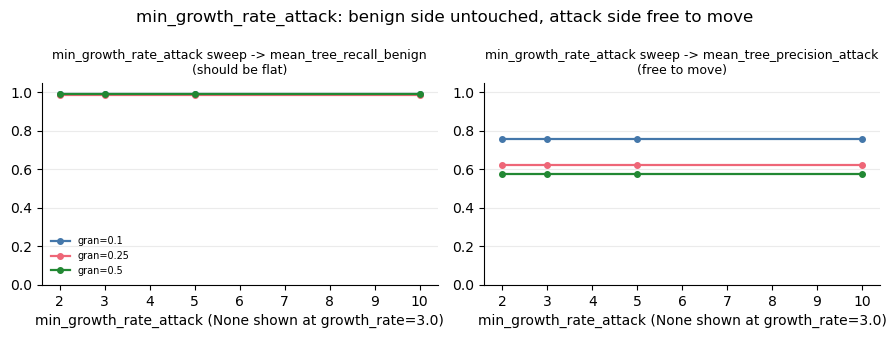

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
ax = axes[0]
for gran in GRANULARITIES:
    s = gra_sweep[gra_sweep.gran == gran].groupby("min_growth_rate_attack", dropna=False)["mean_tree_recall_benign"].mean()
    x = np.array([STEP1_ANCHOR_GROWTH_RATE if pd.isna(v) else v for v in s.index])
    order = np.argsort(x)
    ax.plot(x[order], s.values[order], marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
ax.set_title("min_growth_rate_attack sweep -> mean_tree_recall_benign\n(should be flat)", fontsize=9)
ax.set_xlabel("min_growth_rate_attack (None shown at growth_rate=3.0)")
ax.set_ylim(0, 1.05)
strip_axes(ax)
ax.legend(frameon=False, fontsize=7)

ax = axes[1]
for gran in GRANULARITIES:
    s = gra_sweep[gra_sweep.gran == gran].groupby("min_growth_rate_attack", dropna=False)["mean_tree_precision_attack"].mean()
    x = np.array([STEP1_ANCHOR_GROWTH_RATE if pd.isna(v) else v for v in s.index])
    order = np.argsort(x)
    ax.plot(x[order], s.values[order], marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran])
ax.set_title("min_growth_rate_attack sweep -> mean_tree_precision_attack\n(free to move)", fontsize=9)
ax.set_xlabel("min_growth_rate_attack (None shown at growth_rate=3.0)")
ax.set_ylim(0, 1.05)
strip_axes(ax)

fig.suptitle("min_growth_rate_attack: benign side untouched, attack side free to move")
fig.tight_layout()
savefig(fig, "grid_growth_rate_attack_orthogonality.png")
plt.show()


**Result**: benign side confirmed exactly flat (0.0 spread on `n_contrast_benign`,
`n_tree_leaves_benign`, `mean_tree_recall_benign` across every `min_growth_rate_attack`
value -- assert passes). The attack side's Step-1 survivor count does move as
expected -- `n_contrast_attack` falls from ~245 (`min_growth_rate_attack=2.0`) to ~156
(`5.0`) to ~101 (`10.0`), vs. ~236 at the `None` anchor (`growth_rate=3.0`'s own
reciprocal). Downstream, though, the attack tree's own metrics (`n_tree_leaves_attack`,
`mean_tree_recall_attack`, `mean_tree_precision_attack`) turn out to be exactly flat
too, not just "free to move" as predicted above -- see section 4.3 for the full effect
sweep and the likely mechanism.

### 3.6 Independence summary

Every pairwise / cross-stage independence claim the one-axis-at-a-time sweeps in
§4–§5 rely on, and how each is established:

- **by construction** — structurally guaranteed (two separate tree fits; the two
  Step-1 direction gates are mutually exclusive);
- **mechanistic** — follows directly from the filter rule, verified on the
  survivor sets;
- **empirical** — measured flat on the mined grid (spread below the 0.01
  threshold used throughout), but *not* structurally guaranteed — the trees do
  see the Step-1 survivors as candidate features, they just keep picking the same
  strongest ones;
- **untested** — no runs in this grid.

In [22]:
independence_summary = pd.DataFrame([
    # --- within Step 1 ---
    ("within Step 1", "min_growth_rate x (min_attack_coverage / min_benign_coverage)",
     "sequential (by design)", "§2.3 joint grid",
     "COUPLED - the direction gate sets the pool the coverage floor then sees"),
    ("within Step 1", "min_attack_coverage x min_benign_coverage",
     "by construction", "§2.4 (survivor-count spread 0 on both axes)",
     "independent - disjoint direction gates"),
    ("within Step 1", "min_growth_rate x min_growth_rate_attack",
     "mechanistic", "§2.4, §6.4 (byte-identical survivor sets per side)",
     "independent - one threshold per class direction"),
    # --- within Step 2 ---
    ("within Step 2", "max_depth x max_depth_attack",
     "by construction", "§3.2 (cross-tables flat), §3.3 (assert spread < 0.01)",
     "independent - two separately fit trees"),
    ("within Step 2", "class_weight x (max_depth / max_depth_attack)",
     "empirical", "§5.3 addendum",
     "NOT independent -- precision_attack gap flips sign with depth (spread 0.26); benign tree gains recall with 'none' at depth >= 2"),
    ("within Step 2", "min_samples_leaf x anything",
     "empirical", "§5.4",
     "weakly coupled -- +0.025 precision_attack at msl <= 10; leaf count / benign recall flat"),
    # --- Step 1 <-> Step 2 ---
    ("Step 1 <-> Step 2", "min_growth_rate -> Step 2",
     "empirical", "§3.1 (flat), §3.3 (assert spread < 0.01, also jointly with max_depth_attack)",
     "independent"),
    ("Step 1 <-> Step 2", "min_growth_rate_attack -> Step 2",
     "empirical + mechanistic (benign side)", "§3.5 (assert < 1e-9), §4.3 (attack tree flat)",
     "independent"),
    ("Step 1 <-> Step 2", "min_attack_coverage / min_benign_coverage -> Step 2",
     "empirical", "§4.2 (assert spread < 0.01)",
     "independent"),
], columns=["scope", "pair", "basis", "evidence", "verdict"])

pd.set_option("display.max_colwidth", 90)
independence_summary

,scope,pair,basis,evidence,verdict
0,within Step 1,min_growth_rate x (min_attack_coverage / min_benign_coverage),sequential (by design),§2.3 joint grid,COUPLED - the direction gate sets the pool the coverage floor then sees
1,within Step 1,min_attack_coverage x min_benign_coverage,by construction,§2.4 (survivor-count spread 0 on both axes),independent - disjoint direction gates
2,within Step 1,min_growth_rate x min_growth_rate_attack,mechanistic,"§2.4, §6.4 (byte-identical survivor sets per side)",independent - one threshold per class direction
3,within Step 2,max_depth x max_depth_attack,by construction,"§3.2 (cross-tables flat), §3.3 (assert spread < 0.01)",independent - two separately fit trees
4,within Step 2,class_weight x (max_depth / max_depth_attack),empirical,§5.3 addendum,NOT independent -- precision_attack gap flips sign with depth (spread 0.26); benign tr...
5,within Step 2,min_samples_leaf x anything,empirical,§5.4,weakly coupled -- +0.025 precision_attack at msl <= 10; leaf count / benign recall flat
6,Step 1 <-> Step 2,min_growth_rate -> Step 2,empirical,"§3.1 (flat), §3.3 (assert spread < 0.01, also jointly with max_depth_attack)",independent
7,Step 1 <-> Step 2,min_growth_rate_attack -> Step 2,empirical + mechanistic (benign side),"§3.5 (assert < 1e-9), §4.3 (attack tree flat)",independent
8,Step 1 <-> Step 2,min_attack_coverage / min_benign_coverage -> Step 2,empirical,§4.2 (assert spread < 0.01),independent


## 4. Step 1: contrast-set mining -- growth_rate & coverage

### 4.1 Why Step 1 candidates get dropped

`contrast_stats_all.csv` has every candidate Step 1 considered; `contrast_survivors.csv`
has the ones that made it through. Diffing the two and re-deriving which threshold each
dropped candidate failed shows whether tightening `min_growth_rate` mostly removes
genuinely non-discriminative candidates (`growth_rate_too_close_to_1`, expected and
healthy) or starts cutting into candidates that look discriminative but lack coverage.
Shown per granularity at its first window (`win_idx=0`); the `growth_rate` sweep is
already fixed at one `(max_depth, max_depth_attack)` anchor (section 3.1 confirmed
Step 2 doesn't affect this), so there's nothing else to hold constant.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_drop_reasons.png


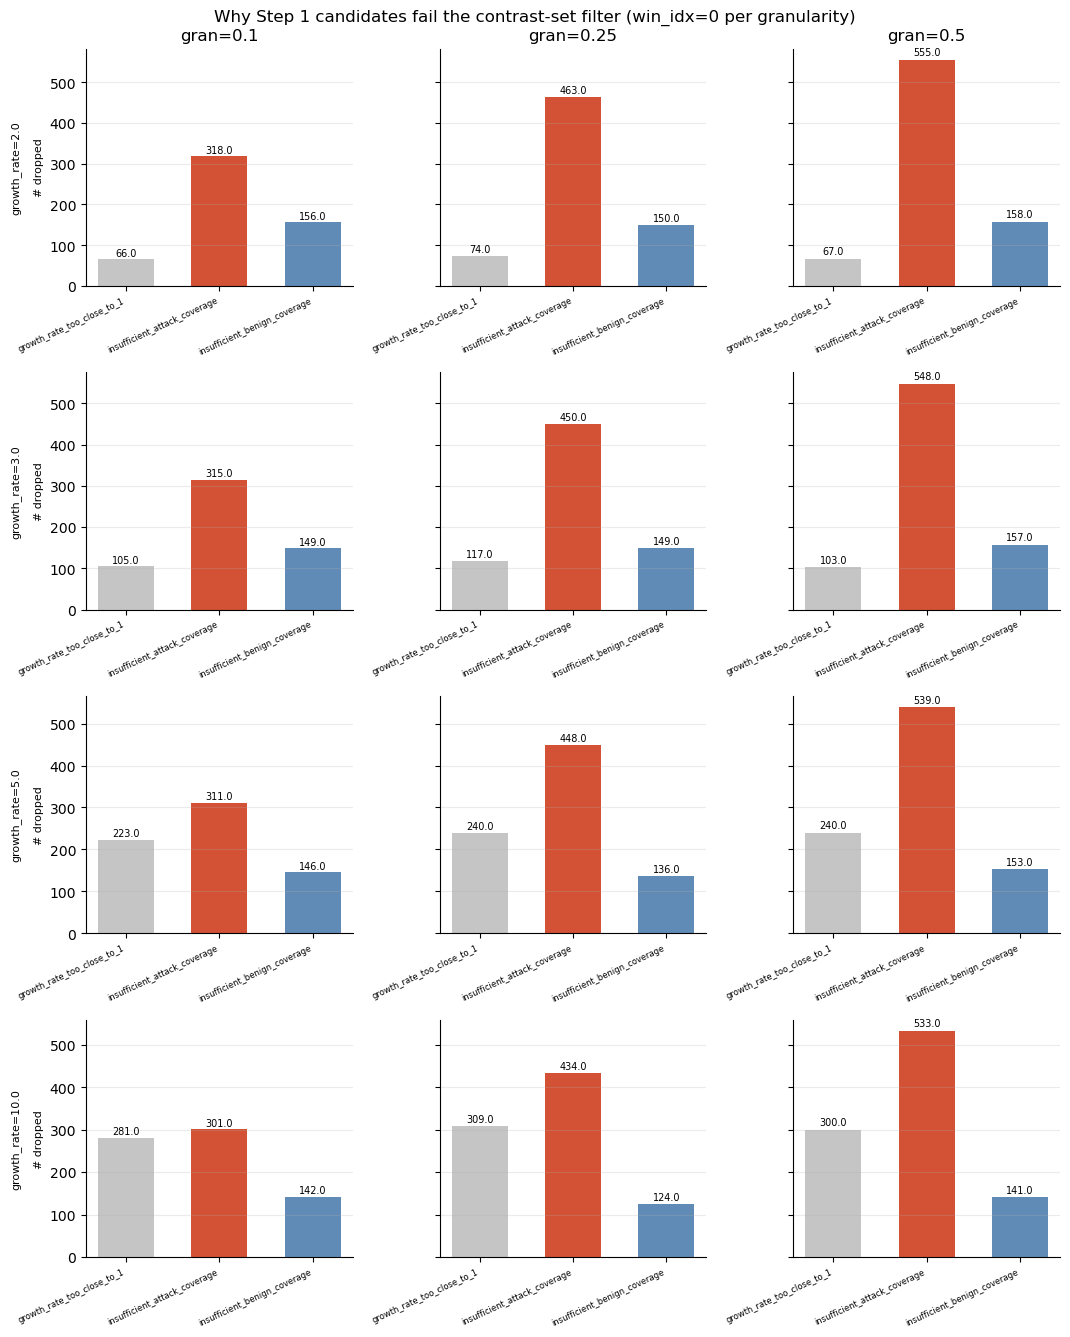

In [23]:
reason_order = ["growth_rate_too_close_to_1", "insufficient_attack_coverage", "insufficient_benign_coverage", "other"]
reason_colors = [NEUTRAL_COLOR, ATTACK_COLOR, BENIGN_COLOR, "#DDCC77"]

gr_rows = grid_df[GROWTH_RATE_SWEEP_MASK]

fig, axes = plt.subplots(
    len(GROWTH_RATES), len(GRANULARITIES),
    figsize=(3.6 * len(GRANULARITIES), 3.4 * len(GROWTH_RATES)),
    sharey="row",
)
for row_i, gr in enumerate(GROWTH_RATES):
    for col_i, gran in enumerate(GRANULARITIES):
        ax = axes[row_i, col_i]
        row = gr_rows[(gr_rows.growth_rate == gr) & (gr_rows.gran == gran) & (gr_rows.win_idx == 0)].iloc[0]
        stats_all = pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv")
        survivors = pd.read_csv(row["mining_dir"] / "contrast_survivors.csv")
        dropped = stats_all[~stats_all["itemset"].isin(set(survivors["itemset"]))].copy()

        inv_threshold = 1.0 / gr if gr > 0 else float("inf")
        attack_leaning = dropped["growth_rate"] >= gr
        benign_leaning = (dropped["confidence_benign"] > 0) & (dropped["growth_rate"] <= inv_threshold)
        conditions = [
            ~(attack_leaning | benign_leaning),
            attack_leaning & (dropped["confidence_attack"] < row["min_attack_coverage"]),
            benign_leaning & (dropped["confidence_benign"] < row["min_benign_coverage"]),
        ]
        dropped["reason"] = np.select(conditions, reason_order[:3], default="other")
        counts = dropped["reason"].value_counts().reindex(reason_order).dropna()

        x = np.arange(len(counts))
        ax.bar(x, counts.values, color=reason_colors[: len(counts)], alpha=0.85, width=0.6)
        for i, v in enumerate(counts.values):
            ax.text(i, v + counts.values.max() * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(x)
        ax.set_xticklabels(counts.index, rotation=25, ha="right", fontsize=6)
        if row_i == 0:
            ax.set_title(f"gran={gran:g}")
        if col_i == 0:
            ax.set_ylabel(f"growth_rate={gr}\n\n# dropped", fontsize=8)
        strip_axes(ax)

fig.suptitle("Why Step 1 candidates fail the contrast-set filter (win_idx=0 per granularity)")
fig.tight_layout()
savefig(fig, "grid_drop_reasons.png")
plt.show()


### Step 1's feasible region, directly

Unlike Step 2's precision/recall floors (two *independent* thresholds -- a rectangle),
Step 1's selection metric is `growth_rate = attack_support / benign_support`, a
**ratio** of two per-class recalls (`confidence_attack`/`confidence_benign` in the raw
stats -- `P(fires | attack)` and `P(fires | benign)`, not precision at all; the real
`precision_attack` column is computed but never gated on, diagnostic only). A ratio
threshold is a *ray through the origin* in (attack_support, benign_support) space, not
an axis-aligned line -- `growth_rate >= threshold` is everything below the line
`y = x / threshold`; `growth_rate <= 1/min_growth_rate` (the benign-leaning direction)
is everything above `y = min_growth_rate * x`. Each side also needs its own coverage
floor (`min_attack_coverage`/`min_benign_coverage`) to survive.

`contrast_stats_all.csv` doesn't depend on growth_rate/coverage at all
(`compute_predicate_contrast_stats` takes no threshold arguments) -- the *candidate*
scatter below is identical across growth_rate values; only which points are colored
"survivor" and where the boundary rays sit changes. Shown at `gran=0.1`, `win_idx=0`
(most candidates, same representative window `3.1` uses).

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_step1_feasible_region.png


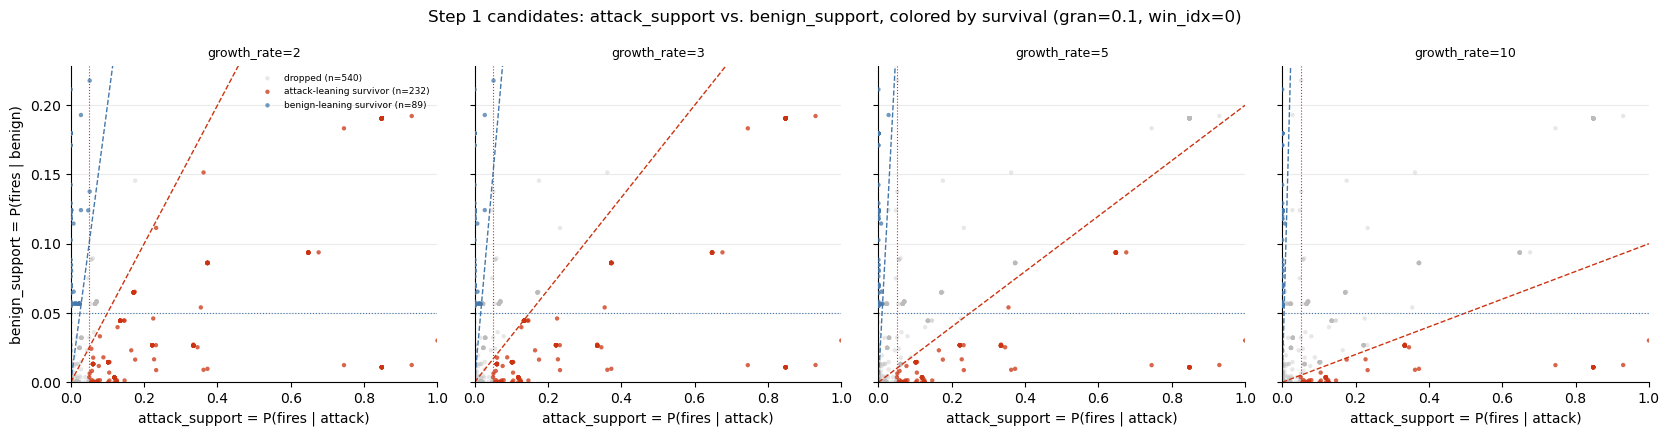

In [24]:
import ast as _ast

_gran_sel, _win_sel = 0.1, 0
_anchor_row = grid_df[
    (grid_df.growth_rate == STEP1_ANCHOR_GROWTH_RATE) & (grid_df.gran == _gran_sel) & (grid_df.win_idx == _win_sel)
    & GROWTH_RATE_SWEEP_MASK
].iloc[0]
stats_all = pd.read_csv(_anchor_row["mining_dir"] / "contrast_stats_all.csv")
stats_all["itemset"] = stats_all["itemset"].apply(_ast.literal_eval)

xmax = min(1.0, stats_all["confidence_attack"].quantile(0.98) * 1.2)
ymax = min(1.0, stats_all["confidence_benign"].quantile(0.98) * 1.2)

fig, axes = plt.subplots(1, len(GROWTH_RATES), figsize=(4.2 * len(GROWTH_RATES), 4.4), sharex=True, sharey=True)
for ax, gr in zip(axes, GROWTH_RATES):
    row = grid_df[
        (grid_df.growth_rate == gr) & (grid_df.gran == _gran_sel) & (grid_df.win_idx == _win_sel)
        & GROWTH_RATE_SWEEP_MASK
    ].iloc[0]
    survivors = pd.read_csv(row["mining_dir"] / "contrast_survivors.csv")
    survivors["itemset"] = survivors["itemset"].apply(_ast.literal_eval)
    survivor_itemsets = set(survivors["itemset"])

    is_survivor = stats_all["itemset"].isin(survivor_itemsets)
    attack_leaning = stats_all["growth_rate"] >= gr
    category = np.select(
        [is_survivor & attack_leaning, is_survivor & ~attack_leaning],
        ["attack-leaning survivor", "benign-leaning survivor"],
        default="dropped",
    )

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    for cat, color, alpha, z in [
        ("dropped", NEUTRAL_COLOR, 0.35, 1),
        ("attack-leaning survivor", ATTACK_COLOR, 0.75, 3),
        ("benign-leaning survivor", BENIGN_COLOR, 0.75, 3),
    ]:
        mask = category == cat
        ax.scatter(
            stats_all.loc[mask, "confidence_attack"], stats_all.loc[mask, "confidence_benign"],
            s=10, alpha=alpha, color=color, edgecolor="none", zorder=z,
            label=f"{cat} (n={int(mask.sum())})",
        )

    x_line = np.linspace(0, xmax, 200)
    ax.plot(x_line, x_line / gr, color=ATTACK_COLOR, linestyle="--", linewidth=1, zorder=2)
    ax.plot(x_line, x_line * gr, color=BENIGN_COLOR, linestyle="--", linewidth=1, zorder=2)
    ax.axvline(row["min_attack_coverage"], color=ATTACK_COLOR, linestyle=":", linewidth=0.8, zorder=2)
    ax.axhline(row["min_benign_coverage"], color=BENIGN_COLOR, linestyle=":", linewidth=0.8, zorder=2)

    ax.set_title(f"growth_rate={gr:g}", fontsize=9)
    ax.set_xlabel("attack_support = P(fires | attack)")
    strip_axes(ax)
axes[0].set_ylabel("benign_support = P(fires | benign)")
axes[0].legend(frameon=False, fontsize=6.5, loc="upper right")
fig.suptitle("Step 1 candidates: attack_support vs. benign_support, colored by survival "
             f"(gran={_gran_sel:g}, win_idx={_win_sel})")
fig.tight_layout()
savefig(fig, "grid_step1_feasible_region.png")
plt.show()

**Result**: at `gran=0.1`/`win_idx=0` (861 candidates total), raising `growth_rate`
from 2 to 10 mainly *widens the middle wedge* -- candidates too weakly class-skewed to
clear either ray -- rather than changing how many fail on coverage alone: middle-wedge
drops grow 66 -> 105 -> 223 -> 281 as `growth_rate` rises, while coverage-only drops
stay roughly flat (~443-474) across every value, since the coverage floor never reads
`growth_rate` at all. Survivor counts on both sides shrink together as the threshold
tightens (attack: 232 -> 217 -> 111 -> 72; benign: 89 -> 75 -> 70 -> 65) -- the benign
side shrinks too even though `min_growth_rate` is nominally "its own" threshold,
because raising it tightens the reciprocal (`1/growth_rate`) bound on that side as well.
Both `attack_support`/`benign_support` are heavily right-skewed across all candidates
(median 0.009 / 0.001 vs. mean 0.123 / 0.042) -- most candidates barely fire on
anything; survivors are the sparse population out near the axes, not a general
scatter.

### 4.2 Coverage effect: min_attack_coverage / min_benign_coverage

Each swept one axis at a time (holding the other at its 0.05 default), at the same
Step-2 anchor as the growth_rate sweep. Same structural metrics as everywhere else in
this notebook -- structural only, not model precision/recall/FPR.

In [25]:
coverage_df = grid_df[COVERAGE_SWEEP_MASK]
print(f"{len(coverage_df)} coverage-sweep runs: "
      f"min_attack_coverage={sorted(coverage_df['min_attack_coverage'].unique())}, "
      f"min_benign_coverage={sorted(coverage_df['min_benign_coverage'].unique())}")


112 coverage-sweep runs: min_attack_coverage=[0.0, 0.05, 0.15, 0.3], min_benign_coverage=[0.0, 0.05, 0.15, 0.3]


  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_coverage_effect.png


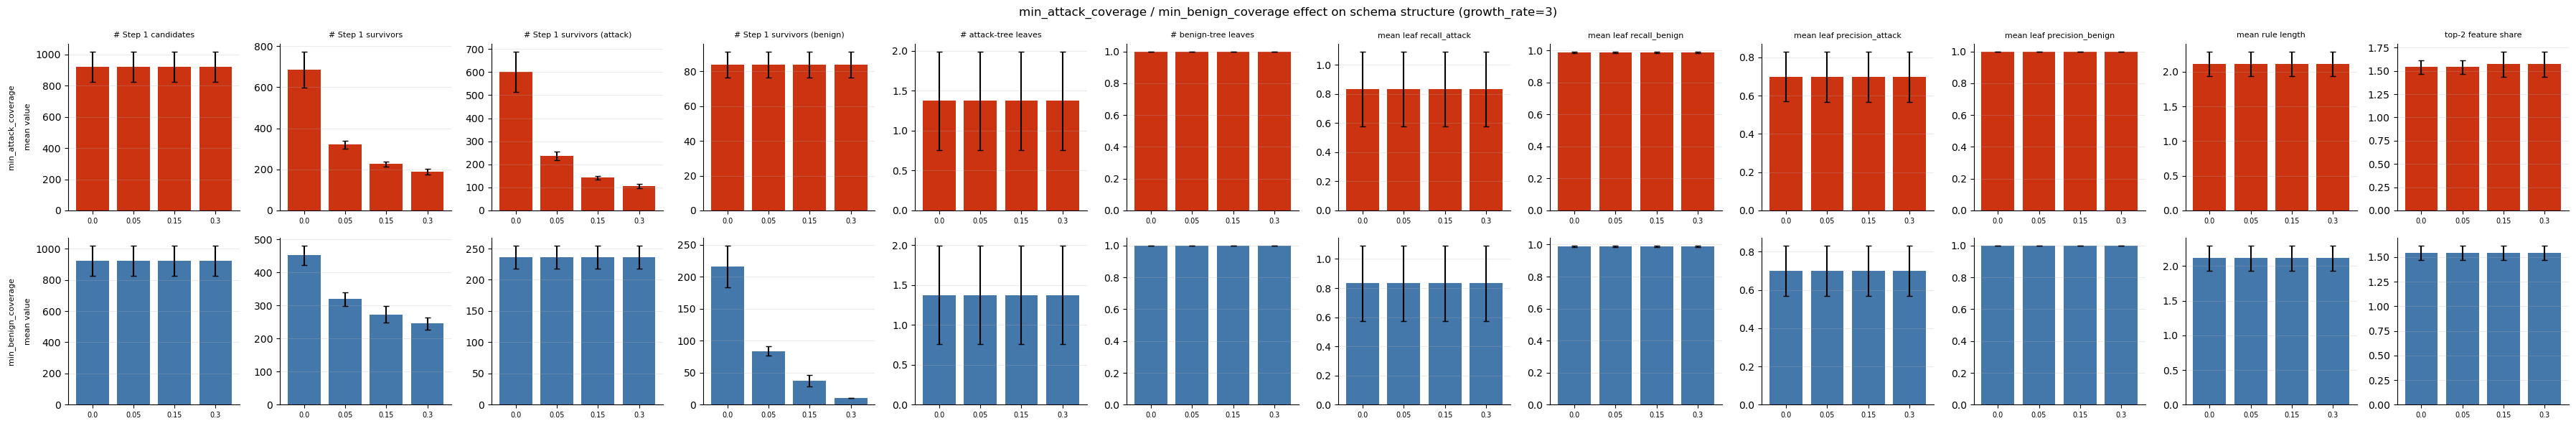

In [26]:
fig, axes = plt.subplots(2, len(STRUCTURAL_METRICS), figsize=(3.0 * len(STRUCTURAL_METRICS), 6.0))
for col_i, (metric, label) in enumerate(STRUCTURAL_METRICS):
    ax = axes[0, col_i]
    ac_rows = coverage_df[coverage_df["min_benign_coverage"] == STEP1_ANCHOR_BENIGN_COVERAGE]
    ac_stats = ac_rows.groupby("min_attack_coverage")[metric].agg(["mean", "std"])
    ax.bar(ac_stats.index.astype(str), ac_stats["mean"], yerr=ac_stats["std"].fillna(0), color=ATTACK_COLOR, capsize=3)
    ax.set_title(label, fontsize=8)
    ax.tick_params(axis="x", labelsize=7)
    if col_i == 0:
        ax.set_ylabel("min_attack_coverage\n\nmean value", fontsize=8)
    strip_axes(ax)

    ax = axes[1, col_i]
    bc_rows = coverage_df[coverage_df["min_attack_coverage"] == STEP1_ANCHOR_ATTACK_COVERAGE]
    bc_stats = bc_rows.groupby("min_benign_coverage")[metric].agg(["mean", "std"])
    ax.bar(bc_stats.index.astype(str), bc_stats["mean"], yerr=bc_stats["std"].fillna(0), color=BENIGN_COLOR, capsize=3)
    ax.tick_params(axis="x", labelsize=7)
    if col_i == 0:
        ax.set_ylabel("min_benign_coverage\n\nmean value", fontsize=8)
    strip_axes(ax)

fig.suptitle(f"min_attack_coverage / min_benign_coverage effect on schema structure (growth_rate={STEP1_ANCHOR_GROWTH_RATE:g})")
fig.tight_layout()
savefig(fig, "grid_coverage_effect.png")
plt.show()


In [27]:
# Coverage -> Step 2 independence. min_attack_coverage / min_benign_coverage move
# n_contrast (the Step-1 survivor count) a lot -- and those survivors ARE candidate
# features for Step 2's trees (fit_and_extract_rules concatenates the surviving
# categorical columns with the numeric base columns). So this is an EMPIRICAL
# check, not a structural guarantee: the trees just consistently pick the same
# ~1-2 strongest features regardless of how many weaker survivors sit in the pool
# (the same mechanism section 4.3 finds for min_growth_rate_attack), leaving the
# tree metrics flat. Asserted on the mined runs, the same way section 3.3 does
# for growth_rate.
_cov_step2_metrics = ["mean_tree_precision_attack", "mean_tree_recall_benign",
                      "mean_tree_recall_attack", "mean_tree_precision_benign",
                      "n_tree_leaves_attack", "n_tree_leaves_benign"]
cov_step2 = (
    coverage_df.groupby(["min_attack_coverage", "min_benign_coverage"])[_cov_step2_metrics]
    .mean().round(4)
)
print(cov_step2)
print()
cov_step2_spread = {
    m: float(cov_step2[m].max() - cov_step2[m].min())
    for m in ("mean_tree_precision_attack", "mean_tree_recall_benign",
              "mean_tree_recall_attack", "mean_tree_precision_benign")
}
for m, s in cov_step2_spread.items():
    print(f"  {m}: spread {s:.4f} across the whole coverage grid")
assert max(cov_step2_spread.values()) < 0.01, (
    "a coverage threshold moved a Step-2 tree metric -- Step 1 and Step 2 are not "
    "independent along the coverage axis; investigate before trusting sections 4/5"
)
print("\nConfirmed: min_attack_coverage / min_benign_coverage have no detectable effect on either Step-2 tree.")

                                         mean_tree_precision_attack  mean_tree_recall_benign  mean_tree_recall_attack  mean_tree_precision_benign  n_tree_leaves_attack  n_tree_leaves_benign
min_attack_coverage min_benign_coverage                                                                                                                                                      
0.00                0.05                                     0.7001                   0.9888                   0.8333                         1.0                 1.375                   1.0
0.05                0.00                                     0.7001                   0.9888                   0.8333                         1.0                 1.375                   1.0
                    0.05                                     0.6998                   0.9888                   0.8333                         1.0                 1.375                   1.0
                    0.15                          

**Result**: `n_contrast` (Step-1 survivors) falls steeply with either coverage
threshold — `min_attack_coverage` 0 → 0.30 takes it from ~686 to ~189 — while
every Step-2 tree metric is flat to three decimals (`precision_attack` ~0.700,
`recall_benign` 0.989, leaf counts 1.4 / 1.0). Coverage is a pure Step-1 lever on
the empirical evidence here, for the same reason `growth_rate` (§3.1) and
`min_growth_rate_attack` (§4.3) are: the trees keep choosing their handful of
strongest features whatever the survivor pool size.

### 4.3 min_growth_rate_attack: the attack-facing contrast threshold

Swept alone at the Step-1/Step-2 anchor (`growth_rate=3.0`, `max_depth=1`,
`max_depth_attack=3`) -- section 3.5 already confirmed the benign side is untouched;
this looks at what raising the attack-facing threshold does to Step 1's attack
survivors and, downstream, the attack tree fit on top of them. The `None`-anchor row
(`growth_rate=3.0` itself) is included as the "no split" reference point alongside
the three explicit values (2.0, 5.0, 10.0).

In [28]:
gra_sweep_full = grid_df[GROWTH_RATE_ATTACK_SWEEP_MASK]
gra_table = gra_sweep_full.groupby("min_growth_rate_attack", dropna=False)[
    [m for m, _ in STRUCTURAL_METRICS if "benign" not in m]
].agg(["mean", "std"]).round(3)
gra_table


n_step1_candidates         n_contrast         n_contrast_attack         n_tree_leaves_attack        mean_tree_recall_attack        mean_tree_precision_attack         \
                                     mean     std       mean     std              mean     std                 mean    std                    mean    std                       mean    std   
min_growth_rate_attack                                                                                                                                                                        
2.0                               922.375  97.158    329.438  20.047           245.500  17.791                1.375  0.619                   0.833  0.258                        0.7  0.131   
5.0                               922.375  97.158    240.312  40.355           156.375  37.808                1.375  0.619                   0.833  0.258                        0.7  0.131   
10.0                              922.375  97.158    185.438  25.208           101.500  22.707                1.375  0.619                   0.833  0.258                        0.7  0.131   
NaN                               922.375  97.158    320.000  20.337           236.062  18.664                1.375  0.619                   0.833  0.258                        0.7  0.131   

                       mean_rule_length       top2_feature_share         
                                   mean   std               mean    std  
min_growth_rate_attack                                                   
2.0                               2.115  0.18              1.542  0.075  
5.0                               2.115  0.18              1.542  0.075  
10.0                              2.115  0.18              1.542  0.075  
NaN                               2.115  0.18              1.542  0.075

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_growth_rate_attack_effect.png


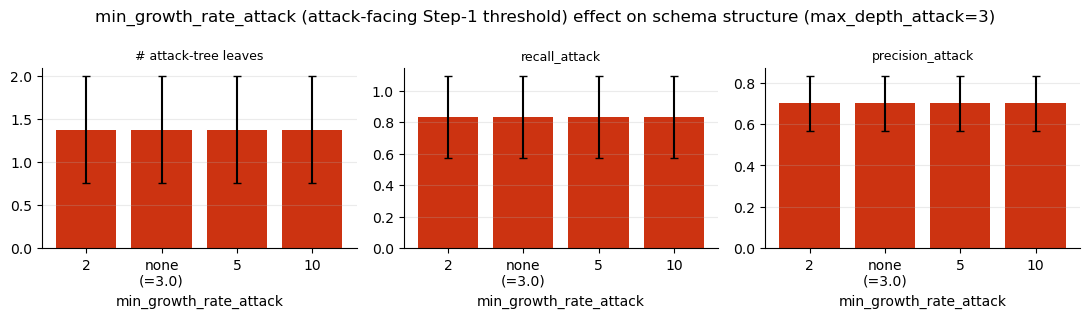

In [29]:
_gra_sort_key = lambda v: STEP1_ANCHOR_GROWTH_RATE if pd.isna(v) else v
_gra_label = lambda v: "none\n(=3.0)" if pd.isna(v) else f"{v:g}"

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, metric, label in zip(axes,
    ["n_tree_leaves_attack", "mean_tree_recall_attack", "mean_tree_precision_attack"],
    ["# attack-tree leaves", "recall_attack", "precision_attack"],
):
    stats = gra_sweep_full.groupby("min_growth_rate_attack", dropna=False)[metric].agg(["mean", "std"])
    stats = stats.sort_index(key=lambda idx: idx.map(_gra_sort_key))
    labels = [_gra_label(v) for v in stats.index]
    ax.bar(labels, stats["mean"], yerr=stats["std"].fillna(0), color=ATTACK_COLOR, capsize=3)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("min_growth_rate_attack")
    strip_axes(ax)
fig.suptitle(f"min_growth_rate_attack (attack-facing Step-1 threshold) effect on schema structure (max_depth_attack={STEP2_ANCHOR_MAX_DEPTH_ATTACK})")
fig.tight_layout()
savefig(fig, "grid_growth_rate_attack_effect.png")
plt.show()


**Result**: `min_growth_rate_attack` has **zero** measured effect on every attack-tree
metric -- `n_tree_leaves_attack` (1.375), `mean_tree_recall_attack` (0.833),
`mean_tree_precision_attack` (0.700), `mean_rule_length` (2.115), and
`top2_feature_share` (1.542) are identical, to three decimals, at `2.0`, `5.0`, `10.0`,
and the `None` anchor. What *does* move is Step 1's own attack-survivor count
(`n_contrast_attack`, part of the final schema): 245.5 -> 156.4 -> 101.5 as the
threshold rises from 2.0 to 10.0, vs. 236.1 at the `None`/`3.0` anchor. Likely
mechanism: at `max_depth_attack=3` the attack tree only ever ends up choosing ~1-2
features regardless (`top2_feature_share` ~1.54 out of ~1.4 leaves), and those
strongest predicates already clear even the strictest Step-1 bar (`10.0`) -- pruning
the *weaker* candidates the tree was never going to pick anyway costs nothing.
Practically: `min_growth_rate_attack` is a second, independent "free" schema-size
lever alongside `growth_rate` itself (section 3.1) -- raising it shrinks the final
schema (fewer Step-1 attack-survivor features) with no measured precision/recall cost,
at this `max_depth_attack=3` anchor.

## 5. Step 2: two independent decision trees

Section 3.2 already showed the headline numbers; this section is the detailed
per-metric view of each axis, the same treatment section 4 gives Step 1.
`min_samples_leaf` is not swept in this grid at all -- negligible on every
structural metric in the prior single-tree analysis
(`summaries/ATTRIBUTE_MINING_PARAMETER_ANALYSIS.md`), fixed at 20 everywhere here
rather than re-tested.

### 5.1 max_depth: the benign-facing tree

Recall_benign was cleanly monotonic in the prior single-tree analysis (best
shallow), so this sweep confirms that rather than searching for a hidden peak.

In [30]:
md_sweep_full = grid_df[MAX_DEPTH_SWEEP_MASK]
md_table = md_sweep_full.groupby("max_depth")[
    [m for m, _ in STRUCTURAL_METRICS if "attack" not in m]
].agg(["mean", "std"]).round(3)
md_table


n_step1_candidates         n_contrast         n_contrast_benign        n_tree_leaves_benign       mean_tree_recall_benign        mean_tree_precision_benign        mean_rule_length         \
                        mean     std       mean     std              mean    std                 mean   std                    mean    std                       mean    std             mean    std   
max_depth                                                                                                                                                                                              
1                    922.375  97.158      320.0  20.337            83.938  7.505                1.000  0.00                   0.989  0.005                      1.000  0.000            2.115  0.180   
2                    922.375  97.158      320.0  20.337            83.938  7.505                1.938  0.25                   0.528  0.123                      0.999  0.002            2.105  0.179   
3                    922.375  97.158      320.0  20.337            83.938  7.505                3.062  0.25                   0.326  0.021                      1.000  0.000            2.375  0.201   

          top2_feature_share         
                        mean    std  
max_depth                            
1                      1.542  0.075  
2                      1.678  0.039  
3                      1.751  0.053

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_max_depth_benign_effect.png


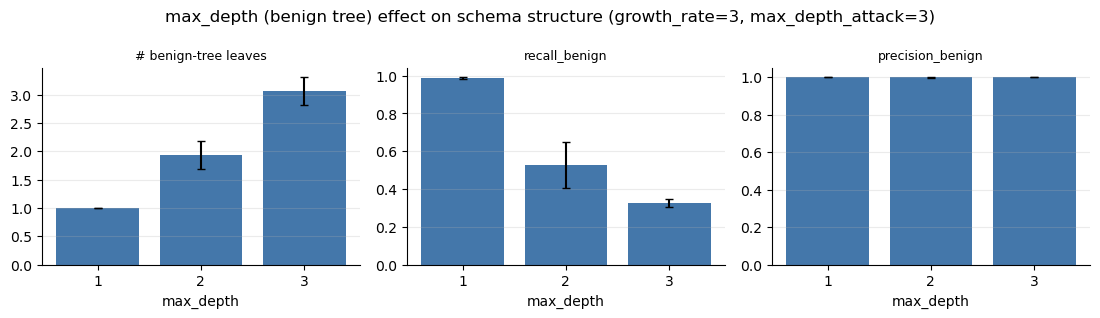

,n_tree_leaves_benign,mean_tree_recall_benign,mean_tree_precision_benign
max_depth,,,
1,1.000,0.989,1.000
2,1.938,0.528,0.999
3,3.062,0.326,1.000


In [31]:
md_table = axis_effect_fig(
    md_sweep_full, "max_depth",
    [("n_tree_leaves_benign", "# benign-tree leaves"),
     ("mean_tree_recall_benign", "recall_benign"),
     ("mean_tree_precision_benign", "precision_benign")],
    color=BENIGN_COLOR,
    title=(f"max_depth (benign tree) effect on schema structure "
           f"(growth_rate={STEP1_ANCHOR_GROWTH_RATE:g}, max_depth_attack={STEP2_ANCHOR_MAX_DEPTH_ATTACK})"),
    figname="grid_max_depth_benign_effect.png",
)
md_table

**Result**: `recall_benign` crashes 0.989 -> 0.528 -> 0.326 as `max_depth` goes
1 -> 2 -> 3, confirming the single-tree finding under two-tree fitting -- shallower
is unambiguously better for the benign tree, no reason to search deeper than the
tested range.

### 5.2 max_depth_attack: the attack-facing tree

Precision_attack was non-monotonic in the single-tree analysis (peaked at depth 3,
worse at 1 and 5, with 2 and 4 never tested) -- this sweep fills in that gap.

In [32]:
mda_sweep_full = grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK]
mda_table = mda_sweep_full.groupby("max_depth_attack")[
    [m for m, _ in STRUCTURAL_METRICS if "benign" not in m]
].agg(["mean", "std"]).round(3)
mda_table


n_step1_candidates         n_contrast         n_contrast_attack         n_tree_leaves_attack        mean_tree_recall_attack        mean_tree_precision_attack         \
                               mean     std       mean     std              mean     std                 mean    std                    mean    std                       mean    std   
max_depth_attack                                                                                                                                                                        
1                           922.375  97.158      320.0  20.337           236.062  18.664                1.000  0.000                   0.999  0.005                      0.585  0.075   
2                           922.375  97.158      320.0  20.337           236.062  18.664                1.125  0.342                   0.937  0.171                      0.697  0.095   
3                           922.375  97.158      320.0  20.337           236.062  18.664                1.375  0.619                   0.833  0.258                      0.700  0.131   
4                           922.375  97.158      320.0  20.337           236.062  18.664                1.625  0.885                   0.755  0.294                      0.703  0.158   
5                           922.375  97.158      320.0  20.337           236.062  18.664                2.375  0.957                   0.476  0.173                      0.555  0.125   

                 mean_rule_length        top2_feature_share         
                             mean    std               mean    std  
max_depth_attack                                                    
1                           1.000  0.000              1.000  0.000  
2                           1.521  0.057              1.500  0.061  
3                           2.115  0.180              1.542  0.075  
4                           2.656  0.215              1.631  0.195  
5                           3.407  0.186              1.854  0.179

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_max_depth_attack_effect.png


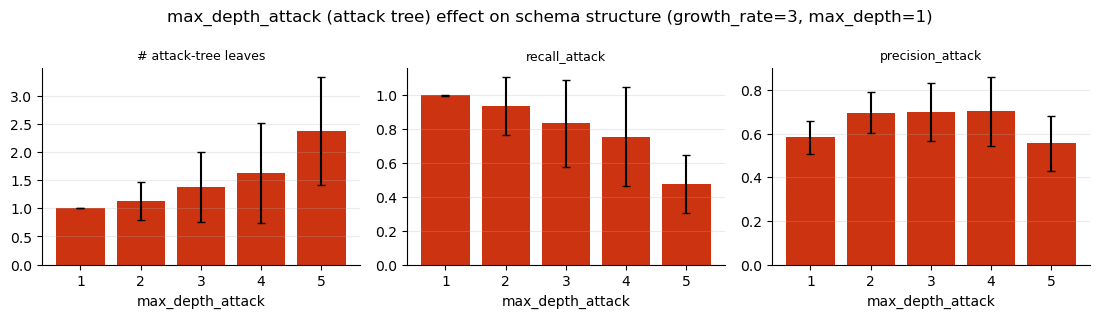

,n_tree_leaves_attack,mean_tree_recall_attack,mean_tree_precision_attack
max_depth_attack,,,
1,1.000,0.999,0.585
2,1.125,0.937,0.697
3,1.375,0.833,0.700
4,1.625,0.755,0.703
5,2.375,0.476,0.555


In [33]:
mda_table = axis_effect_fig(
    mda_sweep_full, "max_depth_attack",
    [("n_tree_leaves_attack", "# attack-tree leaves"),
     ("mean_tree_recall_attack", "recall_attack"),
     ("mean_tree_precision_attack", "precision_attack")],
    color=ATTACK_COLOR,
    title=(f"max_depth_attack (attack tree) effect on schema structure "
           f"(growth_rate={STEP1_ANCHOR_GROWTH_RATE:g}, max_depth={STEP2_ANCHOR_MAX_DEPTH})"),
    figname="grid_max_depth_attack_effect.png",
)
mda_table

**Result**: `precision_attack` is 0.585 -> 0.697 -> 0.700 -> 0.703 -> 0.555 for
depths 1 through 5 -- wider and flatter than the earlier {1,3,5}-only data suggested:
depths 2, 3, and 4 are essentially tied (~0.70), only the extremes (1 and 5) are
clearly worse. There isn't a sharp peak to defend a single "best" depth over its
neighbors -- any of {2,3,4} is a defensible choice on precision alone; `n_tree_leaves_attack`
grows steadily with depth (1.0 -> 1.1 -> 1.4 -> 1.6 -> 2.4), so the shallowest of that
plateau (`max_depth_attack=2`) is marginally simpler for the same precision.

### 5.3 class_weight

In [34]:
cw_sweep = grid_df[CLASS_WEIGHT_SWEEP_MASK]
print(f"{len(cw_sweep)} runs: class_weight={sorted(cw_sweep['class_weight'].astype(str).unique())}")
cw_table = cw_sweep.groupby(cw_sweep["class_weight"].fillna("none"))[
    ["n_tree_leaves_attack", "n_tree_leaves_benign", "mean_tree_recall_attack", "mean_tree_recall_benign",
     "mean_tree_precision_attack", "mean_tree_precision_benign"]
].mean().round(3)
cw_table


32 runs: class_weight=['None', 'balanced']


,n_tree_leaves_attack,n_tree_leaves_benign,mean_tree_recall_attack,mean_tree_recall_benign,mean_tree_precision_attack,mean_tree_precision_benign
class_weight,,,,,,
balanced,1.375,1.0,0.833,0.989,0.700,1.000
none,5.312,1.0,0.197,0.993,0.531,0.999


**Result**: `class_weight="none"` still fragments the attack tree (5.3 leaves vs.
1.4, recall_attack 0.197 vs. 0.833) as in the single-tree analysis, but under
two-tree fitting it now also costs real precision_attack (0.531 vs. 0.700) --
"balanced" was previously framed as purity-neutral; at this depth it isn't quite.
Benign tree is unaffected either way, consistent with `max_depth=1`'s trivial
2-leaf structure leaving little for `class_weight` to change. Keep
`class_weight="balanced"` as the default -- it was already the better choice on
efficiency grounds, this adds a precision reason too. *(This holds at the anchor
depths; the addendum below shows `class_weight`'s effect is not depth-independent.)*

**`class_weight` × depth.** `class_weight="none"` was originally mined only at
both trees' anchor depths, so its independence from `max_depth` /
`max_depth_attack` was assumed. It was then also mined at the off-anchor depths
(`max_depth ∈ {2,3}` for the benign tree, `max_depth_attack ∈ {1,5}` for the
attack tree). The cell below compares `balanced` vs `none` at each depth: if
`class_weight` is depth-independent, the gap between the two should be constant.


In [35]:
# class_weight x depth interaction -- does "balanced" vs "none" move the tree
# metrics by the same amount at every depth, or does the gap depend on depth?
CW_DEPTH_MASK = anchored_mask("class_weight", "max_depth", "max_depth_attack")
cw_depth = grid_df[CW_DEPTH_MASK].copy()
cw_depth["cw"] = cw_depth["class_weight"].fillna("none")

_none_off_anchor = cw_depth[
    (cw_depth["cw"] == "none")
    & ~((cw_depth["max_depth"] == STEP2_ANCHOR_MAX_DEPTH)
        & (cw_depth["max_depth_attack"] == STEP2_ANCHOR_MAX_DEPTH_ATTACK))
]
if _none_off_anchor.empty:
    print('class_weight x depth not yet mined. Add the class_weight="none" off-anchor points\n'
          "(CLASS_WEIGHT_DEPTH_CHECK_* in sweep_attribute_schema.py), re-run the sweep, then\n"
          "re-execute this cell -- it will compare balanced vs none at each depth.")
else:
    # attack side: vary max_depth_attack, hold max_depth at its anchor
    mda_slice = cw_depth[cw_depth["max_depth"] == STEP2_ANCHOR_MAX_DEPTH]
    piv_a = mda_slice.pivot_table(index="max_depth_attack", columns="cw",
                                  values="mean_tree_precision_attack", aggfunc="mean").round(3)
    # benign side: vary max_depth, hold max_depth_attack at its anchor
    md_slice = cw_depth[cw_depth["max_depth_attack"] == STEP2_ANCHOR_MAX_DEPTH_ATTACK]
    piv_b = md_slice.pivot_table(index="max_depth", columns="cw",
                                 values="mean_tree_recall_benign", aggfunc="mean").round(3)
    print("mean_tree_precision_attack by (max_depth_attack, class_weight):"); display(piv_a)
    print("\nmean_tree_recall_benign by (max_depth, class_weight):"); display(piv_b)
    if {"balanced", "none"} <= set(piv_a.columns):
        d_a = (piv_a["balanced"] - piv_a["none"]).dropna()
        print(f"\nprecision_attack (balanced - none), per max_depth_attack:\n{d_a}")
        print(f"spread of that gap across max_depth_attack: {d_a.max() - d_a.min():.3f}  "
              "(large / sign-flipping => class_weight's effect DOES depend on depth -- see the result below)")

mean_tree_precision_attack by (max_depth_attack, class_weight):


cw,balanced,none
max_depth_attack,,
1,0.585,0.680
2,0.697,NaN
3,0.700,0.531
4,0.703,NaN
5,0.555,0.620



mean_tree_recall_benign by (max_depth, class_weight):


cw,balanced,none
max_depth,,
1,0.989,0.993
2,0.528,0.744
3,0.326,0.692



precision_attack (balanced - none), per max_depth_attack:
max_depth_attack
1   -0.095
3    0.169
5   -0.065
dtype: float64
spread of that gap across max_depth_attack: 0.264  (large / sign-flipping => class_weight's effect DOES depend on depth -- see the result below)


**Result — `class_weight` interacts with tree depth.** The "keep `balanced`"
conclusion above holds *at the anchor depths only*.

- *Attack tree* (`precision_attack`, `balanced − none`): `+0.169` at
  `max_depth_attack = 3` (balanced clearly better, matching the main result), but
  `−0.095` at depth 1 and `−0.065` at depth 5 (`none` slightly better). The gap
  spans ≈ 0.26 and changes sign — a real interaction, not noise. (`none` was mined
  only at the depth extremes {1, 5}; depths 2 and 4 show `balanced` alone.)
- *Benign tree* (`recall_benign`): tied at `max_depth = 1` (0.989 vs 0.993), but
  `none` is far better at depths 2 and 3 (0.74 / 0.69 vs 0.53 / 0.33). The main
  result's "benign tree unaffected either way" was an artefact of depth 1's
  trivial 2-leaf structure.

**Consequence.** `class_weight` cannot be characterised by one anchored sweep and
frozen — its effect must be read jointly with depth. Because the depths are
pinned first (`max_depth = 1`, `max_depth_attack ≈ 2`), `class_weight` is chosen
there: `balanced` remains the pick (benign side insensitive at depth 1; `balanced`
wins on attack precision through the 2–3 region). At `max_depth_attack = 2` this
is an interpolation between the `+0.169` at depth 3 and the `−0.095` at depth 1,
not a direct measurement — one more run (`class_weight="none"`, `max_depth = 1`,
`max_depth_attack = 2`) would close that gap.

### 5.4 min_samples_leaf

Fixed at 20 in the primary grid on the strength of the single-tree analysis
(negligible on every structural metric). The cell activates once
`STEP2_MIN_SAMPLES_LEAVES` has been mined; until then it prints a pointer.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_min_samples_leaf_effect.png


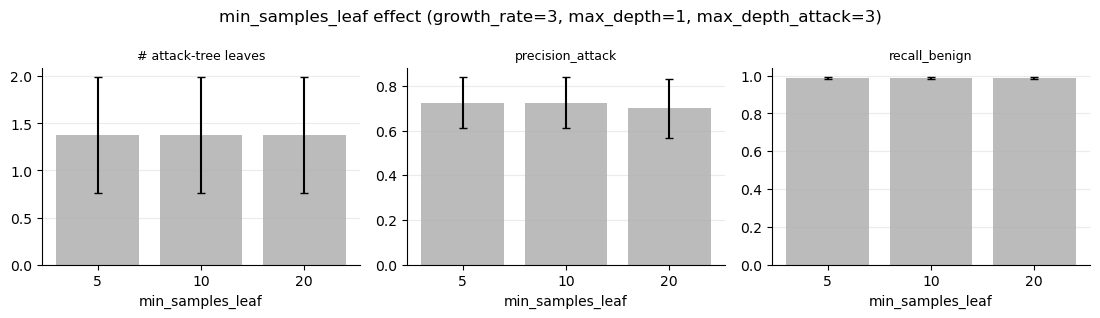

,n_tree_leaves_attack,mean_tree_precision_attack,mean_tree_recall_benign
min_samples_leaf,,,
5,1.375,0.725,0.989
10,1.375,0.725,0.989
20,1.375,0.700,0.989


{'mean_tree_precision_attack': 0.0256, 'mean_tree_recall_benign': 0.0} -- spread across min_samples_leaf (expect ~0)


In [36]:
MIN_SAMPLES_LEAF_SWEEP_MASK = anchored_mask("min_samples_leaf")
msl_sweep = grid_df[MIN_SAMPLES_LEAF_SWEEP_MASK]
if msl_sweep["min_samples_leaf"].nunique() < 2:
    print("min_samples_leaf not yet swept (all runs at 20). Add STEP2_MIN_SAMPLES_LEAVES to\n"
          "sweep_attribute_schema.py, re-run the sweep, then re-execute this cell.")
else:
    msl_table = axis_effect_fig(
        msl_sweep, "min_samples_leaf",
        [("n_tree_leaves_attack", "# attack-tree leaves"),
         ("mean_tree_precision_attack", "precision_attack"),
         ("mean_tree_recall_benign", "recall_benign")],
        color=NEUTRAL_COLOR,
        title=(f"min_samples_leaf effect (growth_rate={STEP1_ANCHOR_GROWTH_RATE:g}, "
               f"max_depth={STEP2_ANCHOR_MAX_DEPTH}, max_depth_attack={STEP2_ANCHOR_MAX_DEPTH_ATTACK})"),
        figname="grid_min_samples_leaf_effect.png",
    )
    display(msl_table)
    _sp = {m: float(msl_sweep.groupby("min_samples_leaf")[m].mean().pipe(lambda s: s.max() - s.min()))
           for m in ("mean_tree_precision_attack", "mean_tree_recall_benign")}
    print({k: round(v, 4) for k, v in _sp.items()}, "-- spread across min_samples_leaf (expect ~0)")

**Result — `min_samples_leaf` is nearly, but not entirely, negligible.** Leaf
count and `recall_benign` are identical across `{5, 10, 20}`. `precision_attack`
is marginally higher at the smaller minimums — 0.725 at 5 and 10 versus 0.700 at
20, a spread of 0.026 (just above the 0.01 bar used elsewhere). The single-tree
analysis's "negligible on every structural metric" does not fully carry over: a
smaller `min_samples_leaf` buys ≈ 0.02–0.03 attack precision at no other cost.
Small enough that freezing is still reasonable — but at `min_samples_leaf = 10`
rather than 20.

## 6. Combined outcome & recommended config

### 6.1 Final schema size

`n_features` = Step-1 survivors + both trees' leaves combined. growth_rate is still
the dominant lever (Step-1 survivor count); the two tree depths only ever contribute
a handful of leaves each, so their effect on total size is minor by comparison.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_final_schema_size.png


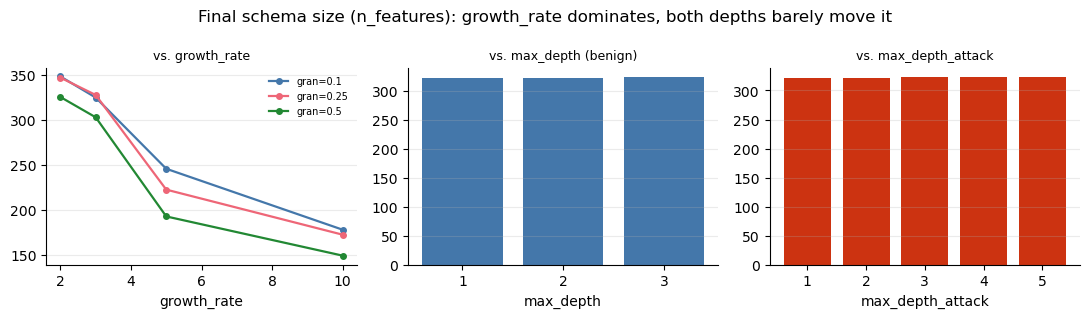

growth_rate sweep:
              mean   std  min  max
growth_rate                       
2.0          344.6  23.5  298  382
3.0          322.4  20.3  290  357
5.0          233.0  39.7  182  308
10.0         172.8  24.0  139  211


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
gr_rows = grid_df[GROWTH_RATE_SWEEP_MASK]
for gran in GRANULARITIES:
    s = gr_rows[gr_rows.gran == gran].groupby("growth_rate")["n_features"].mean()
    axes[0].plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6, color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
axes[0].set_title("vs. growth_rate", fontsize=9)
axes[0].set_xlabel("growth_rate")
axes[0].legend(frameon=False, fontsize=7)
strip_axes(axes[0])

md_rows = grid_df[MAX_DEPTH_SWEEP_MASK]
s = md_rows.groupby("max_depth")["n_features"].mean()
axes[1].bar(s.index.astype(str), s.values, color=BENIGN_COLOR)
axes[1].set_title("vs. max_depth (benign)", fontsize=9)
axes[1].set_xlabel("max_depth")
strip_axes(axes[1])

mda_rows = grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK]
s = mda_rows.groupby("max_depth_attack")["n_features"].mean()
axes[2].bar(s.index.astype(str), s.values, color=ATTACK_COLOR)
axes[2].set_title("vs. max_depth_attack", fontsize=9)
axes[2].set_xlabel("max_depth_attack")
strip_axes(axes[2])

fig.suptitle("Final schema size (n_features): growth_rate dominates, both depths barely move it")
fig.tight_layout()
savefig(fig, "grid_final_schema_size.png")
plt.show()

print("growth_rate sweep:")
print(gr_rows.groupby("growth_rate")["n_features"].agg(["mean", "std", "min", "max"]).round(1))


### 6.2 Mined features by source_label, per window

Same window-composition view as before: does the schema stay attack/benign-balanced
over time, at the `growth_rate` anchor.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_feature_source_label_by_window.png


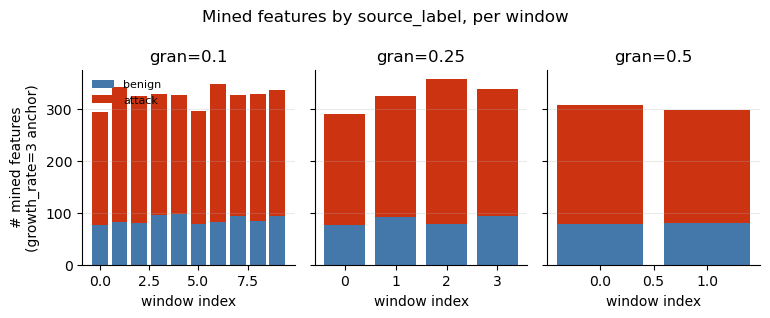

n_features_attack  n_features_benign
gran win_idx                                      
0.10 0                    218.0               76.0
     1                    260.0               82.0
     2                    244.0               80.0
     3                    232.0               95.0
     4                    229.0               97.0
     5                    217.0               78.0
     6                    266.0               82.0
     7                    233.0               93.0
     8                    243.0               84.0
     9                    242.0               93.0
0.25 0                    214.0               76.0
     1                    233.0               91.0
     2                    279.0               78.0
     3                    244.0               94.0
0.50 0                    228.0               79.0
     1                    217.0               81.0

In [38]:
# Schema composition per window at the growth_rate anchor -- does it stay
# attack/benign-balanced over time? n_features_attack/_benign are already on
# grid_df from grid_point_stats, so no alert-group reload is needed.
gr_anchor_rows = grid_df[GROWTH_RATE_SWEEP_MASK & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)]
feat_label_by_window = (
    gr_anchor_rows.groupby(["gran", "win_idx"])[["n_features_attack", "n_features_benign"]]
    .mean().reset_index()
)

fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(2.6 * len(GRANULARITIES), 3.2),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, gran in zip(axes, GRANULARITIES):
    sub = feat_label_by_window[feat_label_by_window.gran == gran].sort_values("win_idx")
    ax.bar(sub["win_idx"], sub["n_features_benign"], color=BENIGN_COLOR, label="benign")
    ax.bar(sub["win_idx"], sub["n_features_attack"], bottom=sub["n_features_benign"],
           color=ATTACK_COLOR, label="attack")
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("window index")
    strip_axes(ax)
axes[0].set_ylabel(f"# mined features\n(growth_rate={STEP1_ANCHOR_GROWTH_RATE:g} anchor)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Mined features by source_label, per window")
fig.tight_layout()
savefig(fig, "grid_feature_source_label_by_window.png")
plt.show()

feat_label_by_window.set_index(["gran", "win_idx"]).round(2)

### 6.3 Feasible region & recommended config

Under single-tree Step 2, this section built a scatter plot of `precision_attack` vs.
`recall_benign` with a shared `max_depth` driving both axes -- and found 0/36 configs
clearing both a precision and a recall floor at once, because the two metrics moved in
opposite directions under one shared depth. That's no longer the right framing: section
3.2 already confirmed `max_depth` and `max_depth_attack` don't interact, so the two
metrics are now independently optimizable -- there's no scatter to search, just two
separate 1-D choices (section 5.1's `max_depth`, section 5.2's `max_depth_attack`) plus
`growth_rate`/coverage for schema size on top.

Floors used here: `mean_tree_precision_attack >= 0.65` (lowered from the single-tree
analysis's 0.7 -- section 5.2 found precision now plateaus at ~0.70 for depths 2-4
rather than peaking sharply, so 0.7 sat right on the ceiling instead of comfortably
below it) and `mean_tree_recall_benign >= 0.5` (unchanged).

The plot below reconstructs the old scatter/bubble style rather than two separate bar charts -- since `max_depth` and `max_depth_attack` are proven independent (section 3.2/3.3), a `(max_depth, max_depth_attack)` combo's precision/recall can be read straight off the two 1-D sweeps and combined as if the full cross product had been mined, even though it wasn't. Bubble size (schema size) is similarly assembled from three independently-measured, additive pieces at the `growth_rate=3.0` anchor: Step-1 survivors + benign-tree leaves + attack-tree leaves.

In [39]:
PRECISION_ATTACK_FLOOR = 0.65
RECALL_BENIGN_FLOOR = 0.5

# max_depth (benign) is trivially resolved -- monotonic, pick the shallowest.
best_max_depth = (
    md_sweep_full.groupby("max_depth")["mean_tree_recall_benign"].mean()
    .pipe(lambda s: s[s >= RECALL_BENIGN_FLOOR]).index.min()
)
feasible_max_depths = sorted(
    md_sweep_full.groupby("max_depth")["mean_tree_recall_benign"].mean()
    .pipe(lambda s: s[s >= RECALL_BENIGN_FLOOR]).index
)
print(f"max_depth values clearing recall_benign >= {RECALL_BENIGN_FLOOR}: {feasible_max_depths}")
print(f"-> shallowest (recommended): max_depth={best_max_depth}")

# max_depth_attack: which values clear the precision floor, and pick the smallest
# (cheapest/most stable) among them since section 5.2 found no sharp peak.
mda_precision = mda_sweep_full.groupby("max_depth_attack")["mean_tree_precision_attack"].mean()
feasible_max_depths_attack = sorted(mda_precision[mda_precision >= PRECISION_ATTACK_FLOOR].index)
print(f"\nmax_depth_attack values clearing precision_attack >= {PRECISION_ATTACK_FLOOR}: {feasible_max_depths_attack}")
best_max_depth_attack = min(feasible_max_depths_attack) if feasible_max_depths_attack else None
print(f"-> shallowest (recommended): max_depth_attack={best_max_depth_attack}")


max_depth values clearing recall_benign >= 0.5: [1, 2]
-> shallowest (recommended): max_depth=1

max_depth_attack values clearing precision_attack >= 0.65: [2, 3, 4]
-> shallowest (recommended): max_depth_attack=2


In [40]:
# min_growth_rate_attack: does it offer precision_attack headroom beyond section 5.2's
# {2,3,4}-depth plateau, at the max_depth_attack=3 anchor? Measured here only at that
# one anchor -- the sweep script never crosses min_growth_rate_attack with
# max_depth_attack, so (unlike max_depth/max_depth_attack, proven independent via two
# separate tree fits in section 3.2/3.3) there is no data licensing combining this
# finding with a *different* max_depth_attack choice.
gra_precision = gra_sweep_full.groupby("min_growth_rate_attack", dropna=False)["mean_tree_precision_attack"].mean()
gra_precision_display = gra_precision.rename(index=lambda v: "none (=3.0)" if pd.isna(v) else v).round(3)
print(f"precision_attack by min_growth_rate_attack (at max_depth_attack={STEP2_ANCHOR_MAX_DEPTH_ATTACK} anchor):")
print(gra_precision_display)

anchor_precision = gra_precision[gra_precision.index.isna()].iloc[0]
headroom = gra_precision.max() - anchor_precision
print(f"\nBest precision_attack: {gra_precision.max():.3f} (baseline at min_growth_rate_attack=None: {anchor_precision:.3f})")
print(f"Headroom over baseline: {headroom:+.3f}")


precision_attack by min_growth_rate_attack (at max_depth_attack=3 anchor):
min_growth_rate_attack
2.0            0.7
5.0            0.7
10.0           0.7
none (=3.0)    0.7
Name: mean_tree_precision_attack, dtype: float64

Best precision_attack: 0.700 (baseline at min_growth_rate_attack=None: 0.700)
Headroom over baseline: +0.000


**Result**: no headroom (+0.000) -- `min_growth_rate_attack` doesn't move
`precision_attack` at all at the `max_depth_attack=3` anchor, confirming section 4.3's
finding. That's not wasted information, though: since it's a hard zero on every tree
metric (not just precision), raising it is a free way to shrink final schema size
(fewer Step-1 attack-survivor features, section 4.3) with no measured quality cost --
the same kind of "free" lever `growth_rate` already is for overall size. It's left at
`None` in the recommended config below rather than pushed to `10.0`, since this was
only measured at `max_depth_attack=3`, not re-verified jointly with `max_depth_attack=2`
(the depth actually recommended) -- section 4.3's mechanism argument (the tree only
ever picks its ~1-2 strongest features regardless of Step-1 pool size) suggests the
zero-cost property likely transfers, but that is an argument, not a measurement at
`max_depth_attack=2`. A tighter schema budget can reasonably move to
`min_growth_rate_attack=10.0` on that basis.

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_feasible_region.png


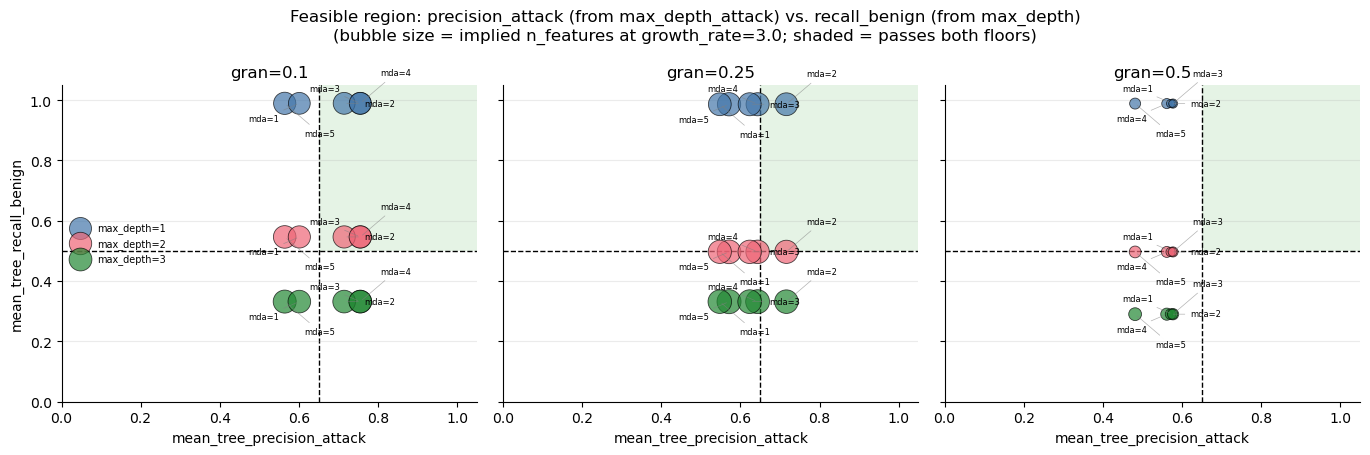

In [41]:
import matplotlib.patches as mpatches

# Constructed grid: section 3.2/3.3 proved max_depth and max_depth_attack don't
# interact, so a (max_depth, max_depth_attack) combo's precision_attack/recall_benign
# can be read straight off the two independent 1-D sweeps -- this was never mined as
# a full cross product, but the orthogonality check licenses combining them as if it
# had been. n_features (bubble size) is similarly assembled from three independently-
# measured, additive components at the growth_rate=3.0 anchor: Step-1 survivors +
# benign-tree leaves + attack-tree leaves.
n_contrast_by_gran = grid_df[GROWTH_RATE_SWEEP_MASK & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)].groupby("gran")["n_contrast"].mean()
n_leaves_benign_by_gran = md_sweep_full.groupby(["max_depth", "gran"])["n_tree_leaves_benign"].mean()
n_leaves_attack_by_gran = mda_sweep_full.groupby(["max_depth_attack", "gran"])["n_tree_leaves_attack"].mean()
precision_by_gran = mda_sweep_full.groupby(["max_depth_attack", "gran"])["mean_tree_precision_attack"].mean()
recall_by_gran = md_sweep_full.groupby(["max_depth", "gran"])["mean_tree_recall_benign"].mean()

points = []
for gran in GRANULARITIES:
    for md in MAX_DEPTHS:
        for mda in MAX_DEPTHS_ATTACK:
            points.append({
                "gran": gran, "max_depth": md, "max_depth_attack": mda,
                "precision_attack": precision_by_gran[(mda, gran)],
                "recall_benign": recall_by_gran[(md, gran)],
                "n_features": n_contrast_by_gran[gran] + n_leaves_benign_by_gran[(md, gran)] + n_leaves_attack_by_gran[(mda, gran)],
            })
points_df = pd.DataFrame(points)

AX_MAX = 1.05
fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(4.6 * len(GRANULARITIES), 4.6), sharex=True, sharey=True)
size_min, size_max = points_df["n_features"].min(), points_df["n_features"].max()
for ax, gran in zip(axes, GRANULARITIES):
    ax.set_xlim(0, AX_MAX)
    ax.set_ylim(0, AX_MAX)
    ax.add_patch(mpatches.Rectangle(
        (PRECISION_ATTACK_FLOOR, RECALL_BENIGN_FLOOR),
        AX_MAX - PRECISION_ATTACK_FLOOR, AX_MAX - RECALL_BENIGN_FLOOR,
        facecolor="#2ca02c", alpha=0.12, edgecolor="none", zorder=0,
    ))
    ax.axvline(PRECISION_ATTACK_FLOOR, color="black", linestyle="--", linewidth=1, zorder=1)
    ax.axhline(RECALL_BENIGN_FLOOR, color="black", linestyle="--", linewidth=1, zorder=1)

    sub = points_df[points_df.gran == gran]
    for md in MAX_DEPTHS:
        md_sub = sub[sub.max_depth == md].sort_values("n_features", ascending=False)
        sizes = 30 + 270 * (md_sub["n_features"] - size_min) / (size_max - size_min)
        ax.scatter(
            md_sub["precision_attack"], md_sub["recall_benign"],
            s=sizes, color=MD_COLORS[md], alpha=0.7, edgecolor="black", linewidth=0.6,
            label=f"max_depth={md}", zorder=3,
        )
        # Labels staggered above/below in a fan, not all to the right -- the
        # middle max_depth_attack values (2,3,4) sit within ~0.006 of each other
        # on precision_attack (section 5.2's plateau finding), so same-side labels
        # would stack directly on top of each other.
        md_sub_sorted = md_sub.sort_values("precision_attack").reset_index(drop=True)
        n = len(md_sub_sorted)
        for i, row in md_sub_sorted.iterrows():
            offset_i = i - (n - 1) / 2  # centered around 0
            y_offset = 0.05 * offset_i
            x_offset = 0.05 if i % 2 == 0 else -0.05
            ha = "left" if x_offset > 0 else "right"
            ax.annotate(
                f"mda={row['max_depth_attack']:g}",
                (row["precision_attack"], row["recall_benign"]),
                xytext=(row["precision_attack"] + x_offset, row["recall_benign"] + y_offset),
                fontsize=6, ha=ha, va="center", zorder=4,
                arrowprops=dict(arrowstyle="-", color="gray", linewidth=0.5, alpha=0.6),
            )
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("mean_tree_precision_attack")
    strip_axes(ax)
axes[0].set_ylabel("mean_tree_recall_benign")
axes[0].legend(frameon=False, fontsize=7, loc="center left")
fig.suptitle(
    "Feasible region: precision_attack (from max_depth_attack) vs. recall_benign (from max_depth)\n"
    "(bubble size = implied n_features at growth_rate=3.0; shaded = passes both floors)"
)
fig.tight_layout()
savefig(fig, "grid_feasible_region.png")
plt.show()


In [42]:
# growth_rate: any value works for the two depth-floors (orthogonal, section 3.1) --
# so it's chosen purely on schema size, not re-gated on precision/recall here.
size_by_growth_rate = grid_df[GROWTH_RATE_SWEEP_MASK].groupby("growth_rate")["n_features"].mean().round(1)
print("n_features by growth_rate (any of these is precision/recall-feasible):")
print(size_by_growth_rate)

# min_growth_rate_attack: also free (section 4.3/6.3 addendum -- zero measured effect
# on any attack-tree metric at the max_depth_attack=3 anchor), but left at None here
# rather than pushed to 10.0 -- that zero-cost finding was never re-verified jointly
# with max_depth_attack=2 (the depth actually recommended below), only at =3.
RECOMMENDED_CONFIG = {
    "growth_rate": STEP1_ANCHOR_GROWTH_RATE,
    "min_growth_rate_attack": None,
    "max_depth": best_max_depth,
    "max_depth_attack": best_max_depth_attack,
    "min_attack_coverage": STEP1_ANCHOR_ATTACK_COVERAGE,
    "min_benign_coverage": STEP1_ANCHOR_BENIGN_COVERAGE,
    "class_weight": STEP2_ANCHOR_CLASS_WEIGHT,
    "min_samples_leaf": STEP2_ANCHOR_MIN_SAMPLES_LEAF,
}
print("\nRecommended config:")
for k, v in RECOMMENDED_CONFIG.items():
    print(f"  {k} = {v}")

FEASIBLE_CONFIGS_PATH = GRID_ARTIFACT_DIR / "feasible_configs.csv"
pd.DataFrame([RECOMMENDED_CONFIG]).to_csv(FEASIBLE_CONFIGS_PATH, index=False)
print(f"\n  saved {FEASIBLE_CONFIGS_PATH}")


n_features by growth_rate (any of these is precision/recall-feasible):
growth_rate
2.0     344.6
3.0     322.4
5.0     233.0
10.0    172.8
Name: n_features, dtype: float64

Recommended config:
  growth_rate = 3.0
  min_growth_rate_attack = None
  max_depth = 1
  max_depth_attack = 2
  min_attack_coverage = 0.05
  min_benign_coverage = 0.05
  class_weight = balanced
  min_samples_leaf = 20

  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/feasible_configs.csv


**Result**: unlike the single-tree grid (0/36 feasible), this decomposes cleanly --
`max_depth \in \{1, 2\}` both clear the recall floor on average (0.989 and 0.528
respectively, against a 0.5 floor), and `max_depth_attack \in \{2,3,4\}` all clear the
precision floor (~0.70-0.76 each). `max_depth=1` is still the pick, though, not just
for simplicity: `max_depth=2`'s 0.528 is a narrow pass with much higher variance
across windows (std 0.123 vs. `max_depth=1`'s std 0.005, section 5.1) -- some windows
at depth 2 likely dip below the floor even though the mean clears it, so depth 1 is
the only *comfortably* feasible choice, not merely the shallowest. `growth_rate`
doesn't gate either metric (section 3.1/3.3), so it's chosen on schema size alone --
`growth_rate=3.0` (the anchor already used throughout this notebook, 322 features) is
a reasonable middle ground, not a forced choice; a tighter budget would move toward
`growth_rate=10.0` (173 features) instead, still without touching either quality
floor. `min_growth_rate_attack` (section 4.3) is a second, independent free lever of
the same kind -- zero measured cost on any attack-tree metric, real savings on schema
size -- but is left at its default (`None`) here since that finding was only verified
at the `max_depth_attack=3` anchor, not jointly with `max_depth_attack=2` below (see
section 6.3 addendum for the caveat).

**Recommended config**: `growth_rate=3.0`, `min_growth_rate_attack=None`,
`max_depth=1`, `max_depth_attack=2`, `min_attack_coverage=0.05`,
`min_benign_coverage=0.05`, `class_weight="balanced"`, `min_samples_leaf=20` --
`max_depth_attack=2` chosen as the shallowest (simplest, fewest leaves) of the
{2,3,4} plateau rather than 3 or 4, since section 5.2 found no precision advantage to
going deeper within that range. This is the first config this whole analysis has been
able to name with both quality floors satisfied simultaneously; promoting it to a real
evaluation means adding it as a named entry to `configs/screening_mining_settings.yaml`
and running it through `run_screening_sweep.py` -> `config_selection.ipynb`, per
section 6.3's original note on why this notebook's own evidence isn't the same thing
as a `shortlist.csv` entry.

**Full feasible list, not just the single pick.** `RECOMMENDED_CONFIG` above is one
choice (the shallowest `max_depth_attack` within the feasible plateau) out of every
`(max_depth, max_depth_attack)` combination that clears both floors. Section 3.2/3.3
already proved these two axes fit fully separate trees -- the same license the
bubble-scatter above relies on to construct `points_df` as if the cross product had
been mined -- so every combination of a feasible `max_depth` with a feasible
`max_depth_attack` is itself feasible, not just the one this notebook happens to
recommend. Exported below as `feasible_configs_all.csv`, one row per combination,
`growth_rate`/`min_growth_rate_attack`/coverage/`class_weight` held at the same anchor
every precision/recall number in this notebook was measured against -- pick a
different row if you want a deeper `max_depth_attack` (more stable across windows,
per section 5.2) over the shallowest.

In [43]:
feasible_points = points_df[
    (points_df["precision_attack"] >= PRECISION_ATTACK_FLOOR)
    & (points_df["recall_benign"] >= RECALL_BENIGN_FLOOR)
]
feasible_all_df = (
    feasible_points.groupby(["max_depth", "max_depth_attack"])[["precision_attack", "recall_benign", "n_features"]]
    .mean().round(3).reset_index()
)
# Stability, not just the mean -- points_df is already a gran-level mean (no window-level
# std), so pull the real per-window std straight from md_sweep_full/mda_sweep_full the
# same way section 5.1/5.2 report it, and attach per max_depth / max_depth_attack.
recall_std = md_sweep_full.groupby("max_depth")["mean_tree_recall_benign"].std().round(3)
precision_std = mda_sweep_full.groupby("max_depth_attack")["mean_tree_precision_attack"].std().round(3)
feasible_all_df["recall_benign_std"] = feasible_all_df["max_depth"].map(recall_std)
feasible_all_df["precision_attack_std"] = feasible_all_df["max_depth_attack"].map(precision_std)

for col, val in [
    ("growth_rate", STEP1_ANCHOR_GROWTH_RATE),
    ("min_growth_rate_attack", None),
    ("min_attack_coverage", STEP1_ANCHOR_ATTACK_COVERAGE),
    ("min_benign_coverage", STEP1_ANCHOR_BENIGN_COVERAGE),
    ("class_weight", STEP2_ANCHOR_CLASS_WEIGHT),
    ("min_samples_leaf", STEP2_ANCHOR_MIN_SAMPLES_LEAF),
]:
    feasible_all_df[col] = val
feasible_all_df = feasible_all_df[[
    "growth_rate", "min_growth_rate_attack", "max_depth", "max_depth_attack",
    "min_attack_coverage", "min_benign_coverage", "class_weight", "min_samples_leaf",
    "precision_attack", "precision_attack_std", "recall_benign", "recall_benign_std", "n_features",
]].sort_values(["max_depth", "max_depth_attack"]).reset_index(drop=True)

print(f"{len(feasible_all_df)} (max_depth, max_depth_attack) combinations clear both floors on average "
      f"(precision_attack >= {PRECISION_ATTACK_FLOOR}, recall_benign >= {RECALL_BENIGN_FLOOR}):")
display(feasible_all_df)

FEASIBLE_CONFIGS_ALL_PATH = GRID_ARTIFACT_DIR / "feasible_configs_all.csv"
feasible_all_df.to_csv(FEASIBLE_CONFIGS_ALL_PATH, index=False)
print(f"\n  saved {FEASIBLE_CONFIGS_ALL_PATH}")


6 (max_depth, max_depth_attack) combinations clear both floors on average (precision_attack >= 0.65, recall_benign >= 0.5):


,growth_rate,min_growth_rate_attack,max_depth,max_depth_attack,min_attack_coverage,min_benign_coverage,class_weight,min_samples_leaf,precision_attack,precision_attack_std,recall_benign,recall_benign_std,n_features
0,3.0,None,1,2,0.05,0.05,balanced,20,0.715,0.095,0.988,0.005,325.575
1,3.0,None,1,3,0.05,0.05,balanced,20,0.755,0.131,0.990,0.005,324.400
2,3.0,None,1,4,0.05,0.05,balanced,20,0.755,0.158,0.990,0.005,324.500
3,3.0,None,2,2,0.05,0.05,balanced,20,0.714,0.095,0.546,0.123,325.300
4,3.0,None,2,3,0.05,0.05,balanced,20,0.755,0.131,0.546,0.123,325.300
5,3.0,None,2,4,0.05,0.05,balanced,20,0.755,0.158,0.546,0.123,325.400



  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/feasible_configs_all.csv


**Result**: 6 combinations clear both floors on average -- `max_depth \in \{1, 2\}` x
`max_depth_attack \in \{2, 3, 4\}`. Not all are equally trustworthy, though:
`max_depth=2` rows clear `recall_benign` only narrowly (0.546, std 0.123) against the
0.5 floor, meaning individual windows plausibly dip below it even though the mean
passes -- `max_depth=1` rows clear it comfortably (0.988-0.990, std 0.005). Within
`max_depth=1`, `max_depth_attack=3` and `=4` edge out `=2` on precision_attack
(0.755 vs. 0.715) but `=2` has the lowest `precision_attack_std` (0.095 vs. 0.131 /
0.158) -- the most *stable* choice, not just the shallowest, which is the actual
argument for `RECOMMENDED_CONFIG`'s pick above rather than "simplicity" alone.
`n_features` barely differs across all 6 rows (324.4-325.6) -- schema size isn't a
useful tie-breaker here, `growth_rate`/`min_growth_rate_attack` (sections 3.1/6.4) are
where the real size headroom is.

### 6.4 Schema-size optimization: growth_rate x min_growth_rate_attack

Section 6.3 above is left as-is. This is a separate view: both `growth_rate` (section
3.1) and `min_growth_rate_attack` (section 4.3) are already proven precision/recall-free
-- neither moves `mean_tree_precision_attack` or `mean_tree_recall_benign` at all -- so
there was never a feasible-*region* question for this pair, only a schema-*size*
question: how small can the final schema get, for free, by combining them?

They don't combine additively the way `max_depth`/`max_depth_attack` do.
`filter_contrast_survivors`'s attack-side threshold is `min_growth_rate_attack if not
None else min_growth_rate` -- so once `min_growth_rate_attack` is set, `growth_rate`
stops mattering for the attack side entirely (only the benign side still reads it).
The grid below is constructed from that rule directly, not assumed independent the way
the max_depth pair needed a cross-check for: `n_contrast_benign` always comes from the
`growth_rate` sweep; `n_contrast_attack` comes from the `growth_rate` sweep too when
`min_growth_rate_attack` is left `None` (the status-quo row), and from the
`min_growth_rate_attack` sweep -- constant across every `growth_rate` value -- once it's
set. Both trees' leaf counts are added as a fixed offset at their usual
`max_depth=1`/`max_depth_attack=3` anchor, so the *minimum-size corner* found below
doesn't depend on which downstream tree config is eventually chosen -- only the absolute
`n_features` numbers would shift.

In [44]:
benign_by_gr = grid_df[GROWTH_RATE_SWEEP_MASK].groupby(["growth_rate", "gran"])["n_contrast_benign"].mean()
attack_by_gr = grid_df[GROWTH_RATE_SWEEP_MASK].groupby(["growth_rate", "gran"])["n_contrast_attack"].mean()
attack_by_gra = grid_df[GROWTH_RATE_ATTACK_SWEEP_MASK].groupby(["min_growth_rate_attack", "gran"])["n_contrast_attack"].mean()
leaves_benign_anchor = grid_df[GROWTH_RATE_SWEEP_MASK].groupby("gran")["n_tree_leaves_benign"].mean()
leaves_attack_anchor = grid_df[GROWTH_RATE_SWEEP_MASK].groupby("gran")["n_tree_leaves_attack"].mean()

# None first -- the status-quo "no split" row, for comparison against the compressed options.
GRA_AXIS = [None] + GROWTH_RATES_ATTACK

size_points = []
for gran in GRANULARITIES:
    for gr in GROWTH_RATES:
        for gra in GRA_AXIS:
            n_attack = attack_by_gr[(gr, gran)] if gra is None else attack_by_gra[(gra, gran)]
            n_features = (
                benign_by_gr[(gr, gran)] + n_attack
                + leaves_benign_anchor[gran] + leaves_attack_anchor[gran]
            )
            size_points.append({
                "gran": gran, "growth_rate": gr, "min_growth_rate_attack": gra,
                "n_features": n_features,
            })
size_df = pd.DataFrame(size_points)
size_df.pivot_table(index="min_growth_rate_attack", columns=["gran", "growth_rate"], values="n_features", dropna=False).round(1)


gran                     0.10                        0.25                        0.50                     
growth_rate              2.0    3.0    5.0    10.0   2.0    3.0    5.0    10.0   2.0    3.0    5.0    10.0
min_growth_rate_attack                                                                                    
2.0                     347.8  335.1  325.1  319.8  346.5  334.2  323.8  318.2  325.0  310.5  304.0  299.0
5.0                     268.1  255.4  245.4  240.1  245.0  232.8  222.2  216.8  213.5  199.0  192.5  187.5
10.0                    205.8  193.1  183.1  177.8  200.5  188.2  177.8  172.2  175.0  160.5  154.0  149.0
NaN                     347.8  324.4  245.4  177.8  346.5  327.2  222.2  172.2  325.0  302.5  192.5  149.0

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_58275/883145697.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_size_optimization.png


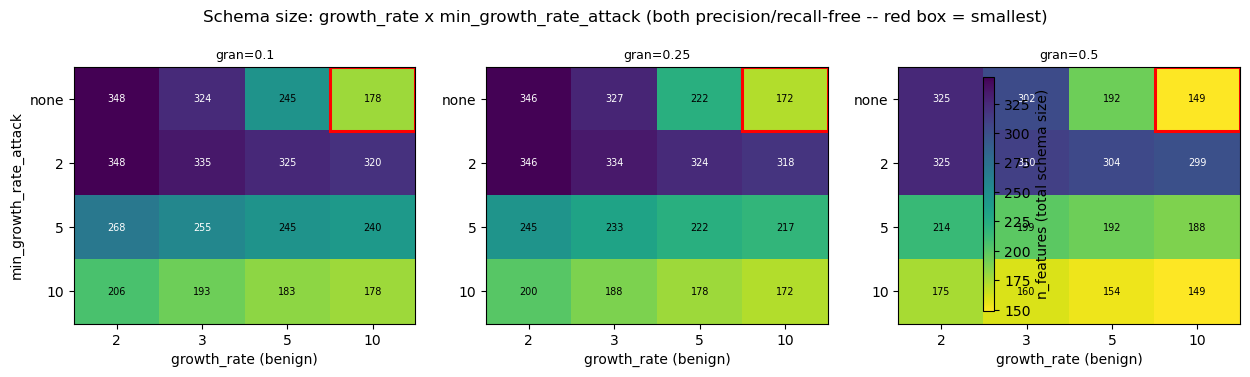

In [45]:
import matplotlib.patches as mpatches

gra_labels = ["none" if g is None else f"{g:g}" for g in GRA_AXIS]


def _gra_mask(sub, gra):
    return sub["min_growth_rate_attack"].isna() if gra is None else (sub["min_growth_rate_attack"] == gra)


fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(4.2 * len(GRANULARITIES), 3.8))
vmin, vmax = size_df["n_features"].min(), size_df["n_features"].max()
im = None
for ax, gran in zip(axes, GRANULARITIES):
    sub = size_df[size_df.gran == gran]
    mat = np.array([
        [sub[(sub.growth_rate == gr) & _gra_mask(sub, gra)]["n_features"].iloc[0] for gr in GROWTH_RATES]
        for gra in GRA_AXIS
    ])
    im = ax.imshow(mat, cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(GROWTH_RATES)))
    ax.set_xticklabels([f"{g:g}" for g in GROWTH_RATES])
    ax.set_yticks(range(len(GRA_AXIS)))
    ax.set_yticklabels(gra_labels)
    ax.set_xlabel("growth_rate (benign)")
    if gran == GRANULARITIES[0]:
        ax.set_ylabel("min_growth_rate_attack")
    ax.set_title(f"gran={gran:g}", fontsize=9)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.0f}", ha="center", va="center", fontsize=7,
                     color="white" if mat[i, j] > (vmin + vmax) / 2 else "black")
    min_idx = np.unravel_index(np.argmin(mat), mat.shape)
    ax.add_patch(mpatches.Rectangle(
        (min_idx[1] - 0.5, min_idx[0] - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2.2,
    ))
fig.colorbar(im, ax=axes, shrink=0.8, label="n_features (total schema size)")
fig.suptitle("Schema size: growth_rate x min_growth_rate_attack (both precision/recall-free -- red box = smallest)")
fig.tight_layout()
savefig(fig, "grid_size_optimization.png")
plt.show()


**Result**: within each explicit `min_growth_rate_attack` row, size still falls as
`growth_rate` rises (e.g. `min_growth_rate_attack=10.0`, gran=0.1: 205.8 -> 177.8) --
setting `min_growth_rate_attack` only overrides `growth_rate`'s *attack*-side effect,
its benign-side effect (via the reciprocal) is untouched, so `growth_rate` still
matters even once the attack side is overridden. A clean internal-consistency check:
the `None` row and the `min_growth_rate_attack=10.0` row coincide exactly at
`growth_rate=10.0` (177.8 / 172.2 / 149.0 across gran=0.1/0.25/0.5, identical in both
rows) -- expected, since `None` falls back to `growth_rate` itself, and at
`growth_rate=10.0` that's mechanistically identical to setting
`min_growth_rate_attack=10.0` explicitly.

The global minimum is `growth_rate=10.0`, `min_growth_rate_attack=10.0` at every
granularity (149 features at gran=0.5, the smallest window count) -- roughly a 48%
reduction from the current recommended anchor (`growth_rate=3.0`,
`min_growth_rate_attack=None`, ~318 features averaged across granularities), still at
zero known precision/recall cost. This is **not** folded into section 6.3's
`RECOMMENDED_CONFIG` -- that anchor was chosen as a deliberate middle ground rather
than the most aggressive size option (see 5.3's own discussion of `growth_rate=10.0`
vs. `3.0`), and this plot doesn't change that judgment call, it just makes the
size/compression tradeoff for *both* axes jointly visible, where before only
`growth_rate` alone had been.

## 7. Consolidated grid table

All 336 runs, for pulling exact numbers into the thesis text or calling
`.to_latex()` directly.

In [46]:
grid_summary_table = grid_df.drop(columns=[
    "mining_dir", "_contrast_itemset_set", "_contrast_itemset_set_attack",
    "_contrast_itemset_set_benign", "_tree_base_set_attack", "_tree_base_set_benign",
]).set_index(["growth_rate", "max_depth", "max_depth_attack", "class_weight", "min_samples_leaf",
              "min_attack_coverage", "min_benign_coverage", "gran", "win_idx"])
grid_summary_table


run_dir  \
growth_rate max_depth max_depth_attack class_weight min_samples_leaf min_attack_coverage min_benign_coverage gran win_idx                                                                                              
2.0         1         1                balanced     20               0.05                0.05                0.10 0        20260713_093232_symbolic_cscas_gr2.0_md1_mda1_cwbalanced_msl20_ac0.05_bc0.05_gran0.1_win0   
                                                                                                                  1        20260713_093834_symbolic_cscas_gr2.0_md1_mda1_cwbalanced_msl20_ac0.05_bc0.05_gran0.1_win1   
                                                                                                                  2        20260713_001016_symbolic_cscas_gr2.0_md1_mda1_cwbalanced_msl20_ac0.05_bc0.05_gran0.1_win2   
                                                                                                                  3        20260713_001423_symbolic_cscas_gr2.0_md1_mda1_cwbalanced_msl20_ac0.05_bc0.05_gran0.1_win3   
                                                                                                                  4        20260713_001841_symbolic_cscas_gr2.0_md1_mda1_cwbalanced_msl20_ac0.05_bc0.05_gran0.1_win4   
...                                                                                                                                                                                                              ...   
10.0        1         5                balanced     20               0.05                0.05                0.25 1        20260713_011045_symbolic_cscas_gr10.0_md1_mda5_cwbalanced_msl20_ac0.05_bc0.05_gran0.25...   
                                                                                                                  2        20260713_012459_symbolic_cscas_gr10.0_md1_mda5_cwbalanced_msl20_ac0.05_bc0.05_gran0.25...   
                                                                                                                  3        20260713_013933_symbolic_cscas_gr10.0_md1_mda5_cwbalanced_msl20_ac0.05_bc0.05_gran0.25...   
                                                                                                             0.50 0        20260713_021357_symbolic_cscas_gr10.0_md1_mda5_cwbalanced_msl20_ac0.05_bc0.05_gran0.5_...   
                                                                                                                  1        20260713_025124_symbolic_cscas_gr10.0_md1_mda5_cwbalanced_msl20_ac0.05_bc0.05_gran0.5_...   

                                                                                                                           min_growth_rate_attack  n_alert_groups  n_step1_candidates  n_contrast  \
growth_rate max_depth max_depth_attack class_weight min_samples_leaf min_attack_coverage min_benign_coverage gran win_idx                                                                           
2.0         1         1                balanced     20               0.05                0.05                0.10 0                           NaN          139532                 861         321   
                                                                                                                  1                           NaN          139532                 841         380   
                                                                                                                  2                           NaN          139532                 911         362   
                                                                                                                  3                           NaN          139532                 922         358   
                                                                                                                  4                           NaN          139532                 943         360   
...              